In [1]:
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

import joblib
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

from sklearn.base import clone
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score, 
    brier_score_loss,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    matthews_corrcoef, 
    classification_report)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore', message='Could not find the number of physical cores')

import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

In [2]:
#!pip install xgboost -q

In [3]:
SERVICE = ['target', 'demand', 'oot']
RANDOM_STATE = 42

In [4]:
df = pd.read_csv('df_for_analyzing_feats.csv')

In [5]:
df

,demand,target,oot,ltv_avg,comis_to_debt_ratio_last,comis_to_paym_ratio,comis_to_paym_ratio_last,dop_second_service_ratio,dop_first_service_ratio,dop_ratio,dop_sum_ratio_max,dop_sum_ratio_last,avg_order_time,fact_order_sum_to_asked_max,fact_order_sum_to_asked_last,pl_last,age,gender,call_cnt_last,cnt_calls_all,appeal_last_em,avg_appeal_em,all_appeal_em,appeal_last_lk,all_appeal_lk,avg_start_amount_inc_ratio,amount_inc_ratio_last,sum_ratio_upto5,extens_ratio,period30_ratio,dops_inc_ratio_last,avg_cnt_session,cnt_all_session,avg_approve,dop_sum_ratio,ltv,days_after_order_time,order_number,delay_ratio,avg_fact_order_sum,time_btw_last_order,lifetime_start_last,order_time_last_ratio
0,23809874,1,0,8144.910,0.290,0.090,0.090,1.000,1.000,1.000,0.600,0.000,69.000,1.000,1.000,16.290,20.000,1,0,0,0,0.000,0,0,0,0.080,0.080,1.000,1.000,1.000,0.000,10.000,11,1.000,0.600,8144.914,69,1,0.000,4000.000,NaN,22,3.182
1,23810121,1,0,4923.760,0.160,0.100,0.100,1.000,1.000,1.000,0.300,0.000,16.000,1.000,1.000,4.920,25.000,1,0,0,0,0.000,0,0,0,0.110,0.110,0.000,0.000,1.000,0.000,8.000,9,1.000,0.300,4923.763,16,1,1.000,8000.000,NaN,16,1.062
2,23845577,0,0,3257.540,0.290,0.140,0.140,1.000,1.000,1.000,0.800,0.000,5.000,1.000,1.000,15.200,39.000,1,0,0,0,0.000,0,0,0,0.060,0.060,1.000,0.000,1.000,0.000,2.000,4,1.000,0.800,3257.543,5,1,1.000,3000.000,NaN,16,0.375
3,24846191,0,0,4387.870,0.160,0.110,0.090,1.000,1.000,1.000,0.800,0.300,14.000,1.000,1.000,9.660,39.000,1,0,0,0,0.000,0,0,0,0.110,0.160,0.500,0.000,0.500,0.050,3.000,9,1.000,0.436,8775.745,53,2,1.000,5500.000,25.000,26,0.923
4,30554758,1,0,4193.630,0.200,0.110,0.110,1.000,1.000,1.000,0.800,0.480,12.000,1.000,1.000,10.650,39.000,1,0,0,0,0.000,0,0,0,0.110,0.100,0.670,0.000,0.330,0.050,3.000,19,1.000,0.450,12580.888,211,3,1.000,5333.333,150.000,16,0.562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321437,46765176,0,0,3193.600,0.080,0.060,0.060,1.000,1.000,1.000,0.240,0.000,7.000,1.000,1.000,3.190,20.000,1,0,0,0,0.000,0,0,0,0.330,0.330,0.000,0.000,1.000,0.000,1.000,2,1.000,0.240,3193.600,7,1,1.000,10000.000,NaN,30,0.233
321438,48222616,0,0,3653.120,0.130,0.080,0.090,1.000,1.000,1.000,0.240,0.240,6.000,1.000,1.000,4.110,21.000,1,0,0,0,0.000,0,0,0,0.330,0.330,0.000,0.000,0.500,0.080,1.000,7,1.000,0.240,7306.243,38,2,1.000,10000.000,26.000,21,0.238
321439,49464215,0,0,3693.070,0.130,0.080,0.090,1.000,1.000,1.000,0.240,0.240,4.000,1.000,0.670,3.770,21.000,1,0,0,0,0.000,0,0,0,0.390,0.330,0.000,0.000,0.670,0.080,0.670,8,1.000,0.240,11079.205,62,3,1.000,10000.000,24.000,19,0.000
321440,49512219,0,0,3734.270,0.130,0.090,0.090,1.000,1.000,1.000,0.240,0.240,3.000,1.000,1.000,3.860,21.000,1,0,0,0,0.000,0,0,0,0.380,0.330,0.000,0.000,0.750,0.080,0.500,14,1.000,0.240,14937.088,65,4,1.000,10000.000,1.000,18,0.111


## Анализ признаков

In [6]:
def split_feats(df):
    work_cols = [c for c in df.columns if c not in SERVICE]

    num_all = df[work_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_all = df[work_cols].select_dtypes(include=['object', 'category']).columns.tolist()

    num_cols = [c for c in num_all if df[c].nunique() > 20]
    cat_cols = cat_all + [c for c in num_all if df[c].nunique() <= 20]
    
    return num_cols, cat_cols

In [7]:
num_cols, cat_cols = split_feats(df)

In [8]:
print(num_cols)
print(f'\n{cat_cols}')

['ltv_avg', 'comis_to_debt_ratio_last', 'comis_to_paym_ratio', 'comis_to_paym_ratio_last', 'dop_sum_ratio_max', 'dop_sum_ratio_last', 'avg_order_time', 'fact_order_sum_to_asked_max', 'fact_order_sum_to_asked_last', 'pl_last', 'age', 'cnt_calls_all', 'avg_appeal_em', 'avg_start_amount_inc_ratio', 'amount_inc_ratio_last', 'sum_ratio_upto5', 'extens_ratio', 'period30_ratio', 'dops_inc_ratio_last', 'avg_cnt_session', 'cnt_all_session', 'avg_approve', 'dop_sum_ratio', 'ltv', 'days_after_order_time', 'order_number', 'delay_ratio', 'avg_fact_order_sum', 'time_btw_last_order', 'order_time_last_ratio']

['dop_second_service_ratio', 'dop_first_service_ratio', 'dop_ratio', 'gender', 'call_cnt_last', 'appeal_last_em', 'all_appeal_em', 'appeal_last_lk', 'all_appeal_lk', 'lifetime_start_last']


In [9]:
def analyze_nums(df, num_cols):
    for col in num_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        sns.kdeplot(data=df, x=col, hue='target', common_norm=False, ax=axes[0])
        axes[0].set_title(f'Связь {col} с target')
        
        sns.boxplot(data=df, x='target', y=col, ax=axes[1])
        axes[1].set_title(f'Boxplot {col}')
        
        plt.tight_layout()
        plt.show()

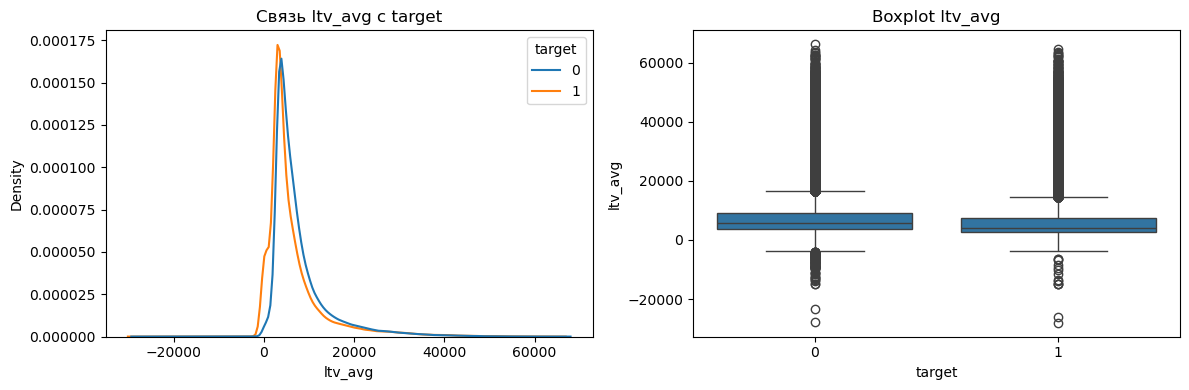

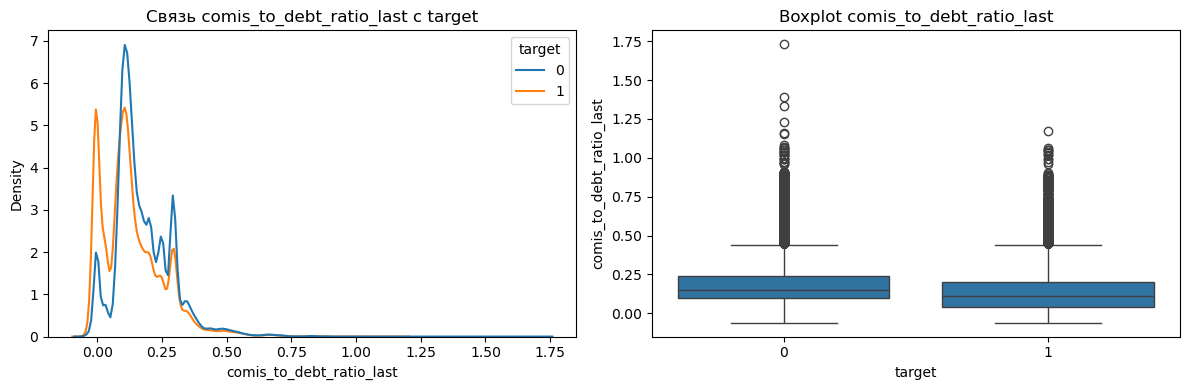

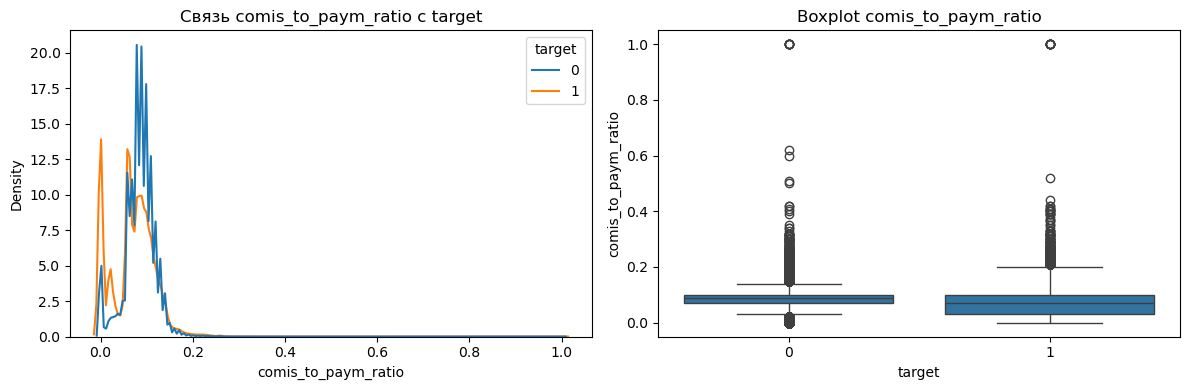

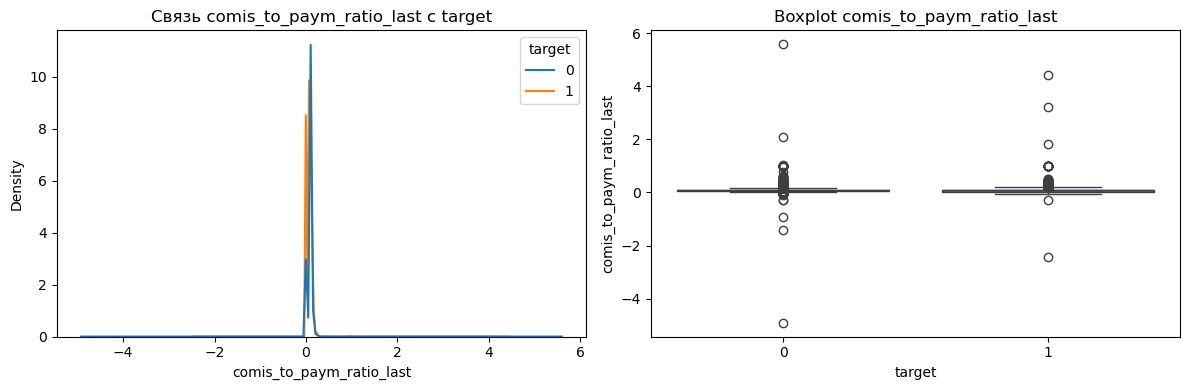

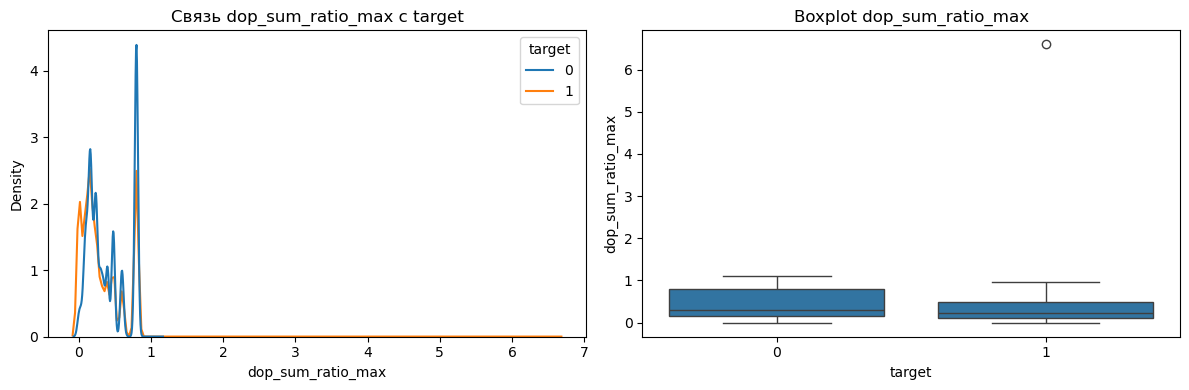

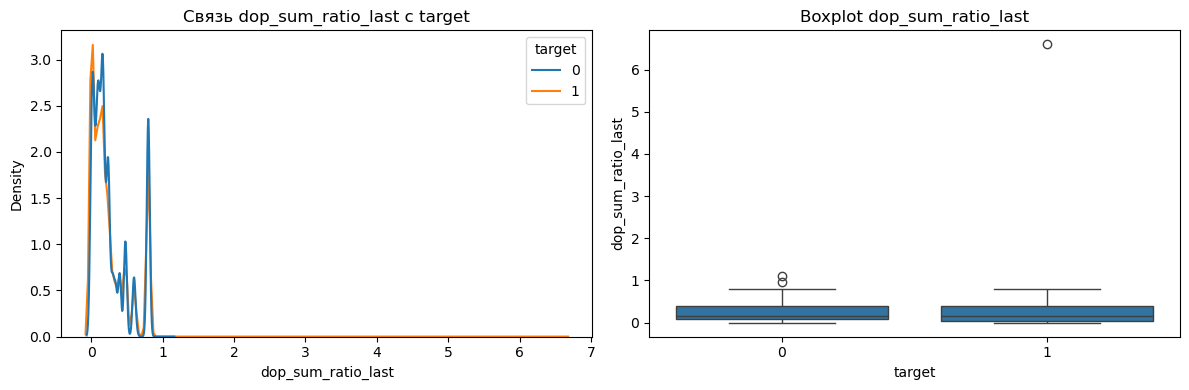

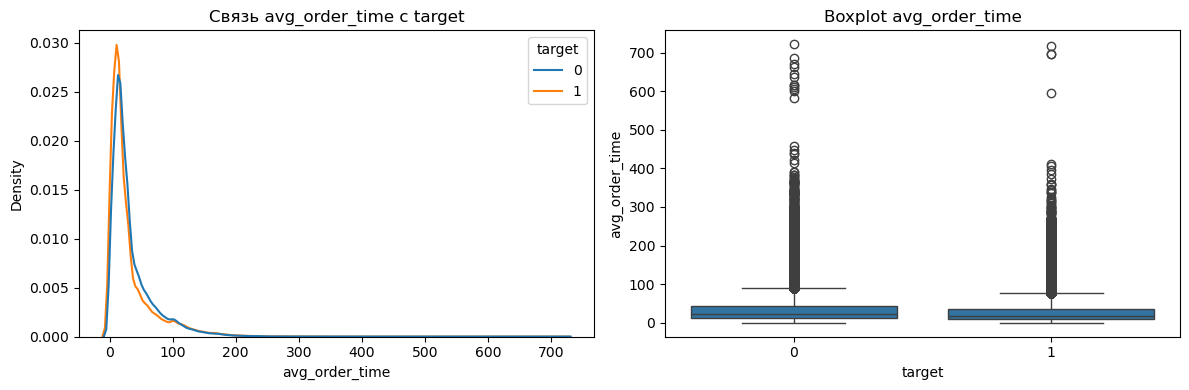

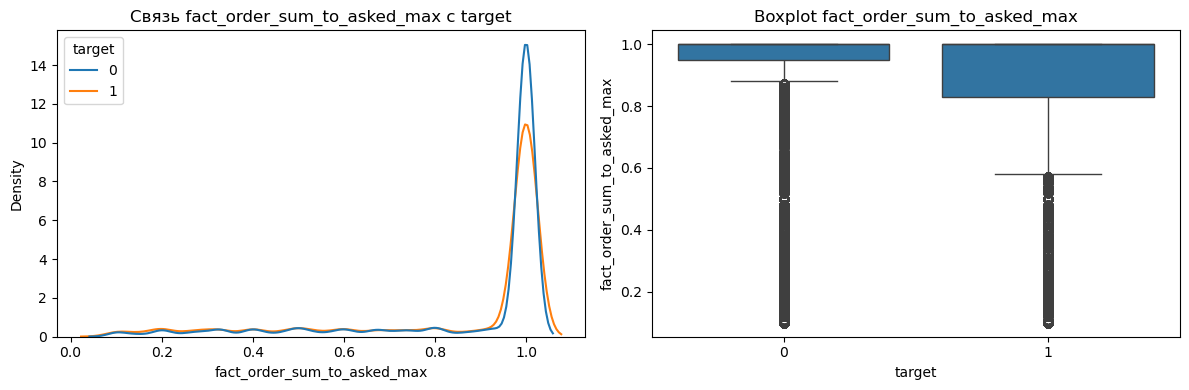

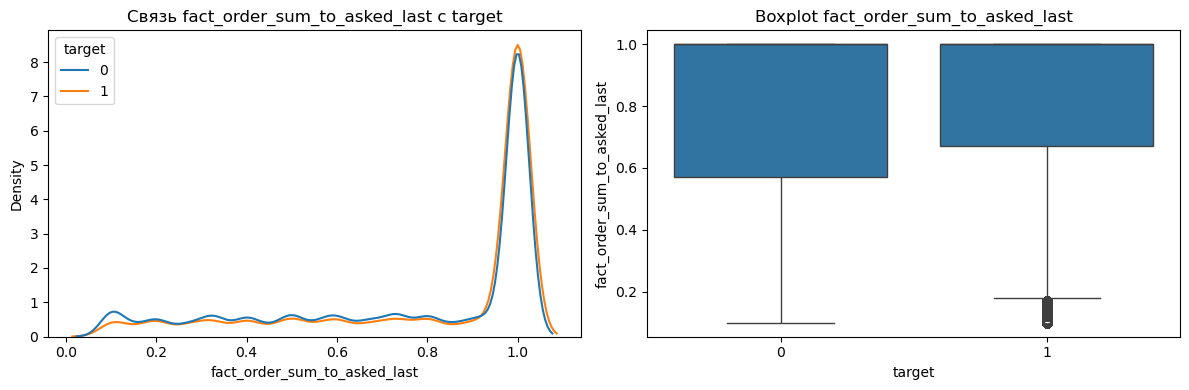

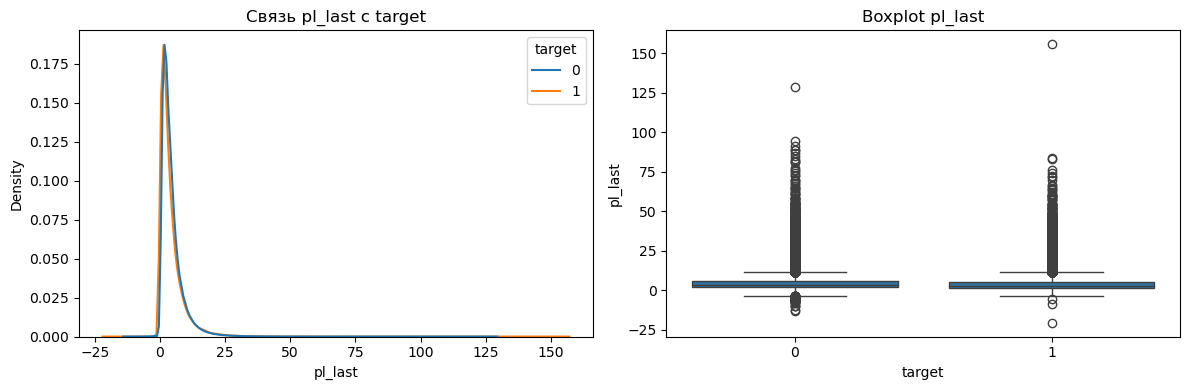

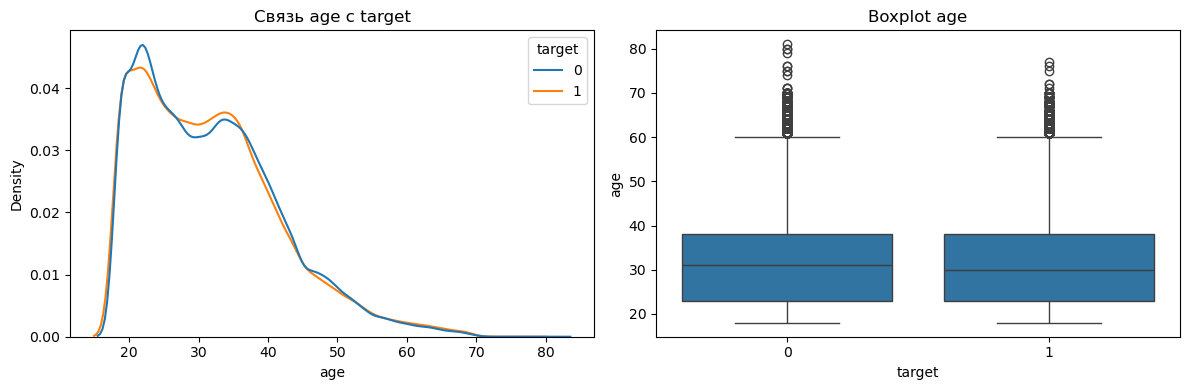

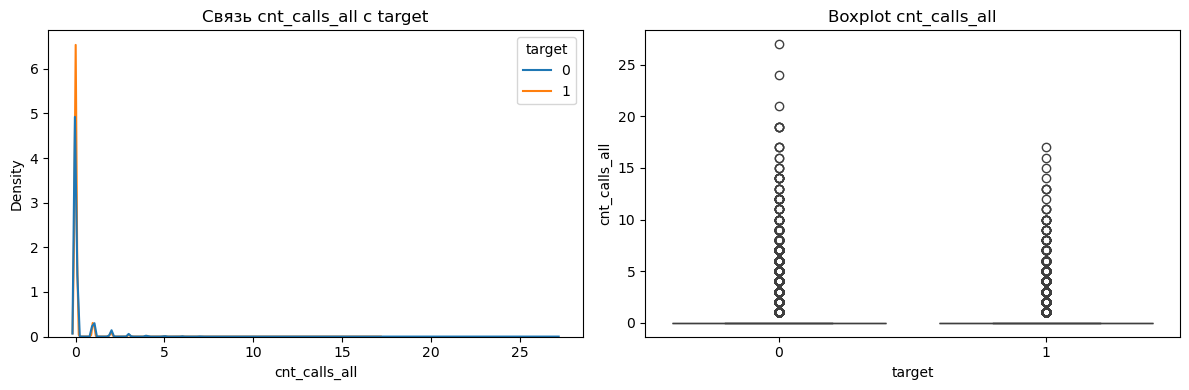

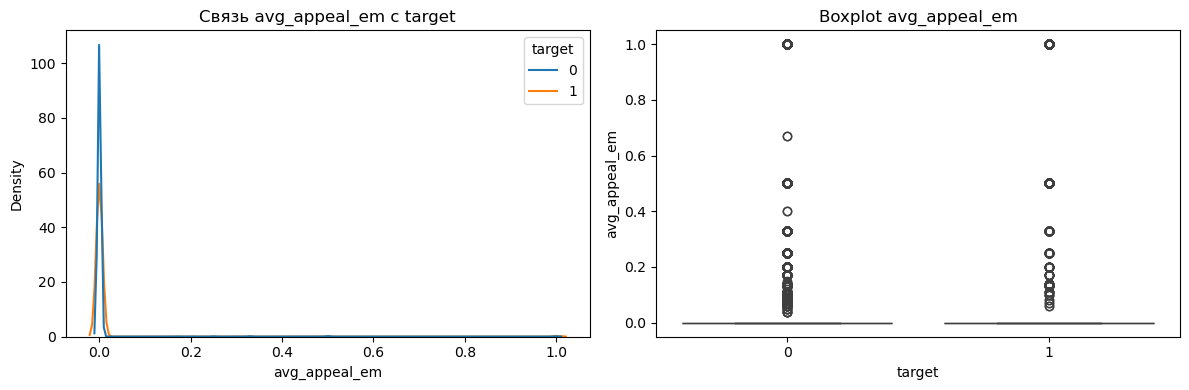

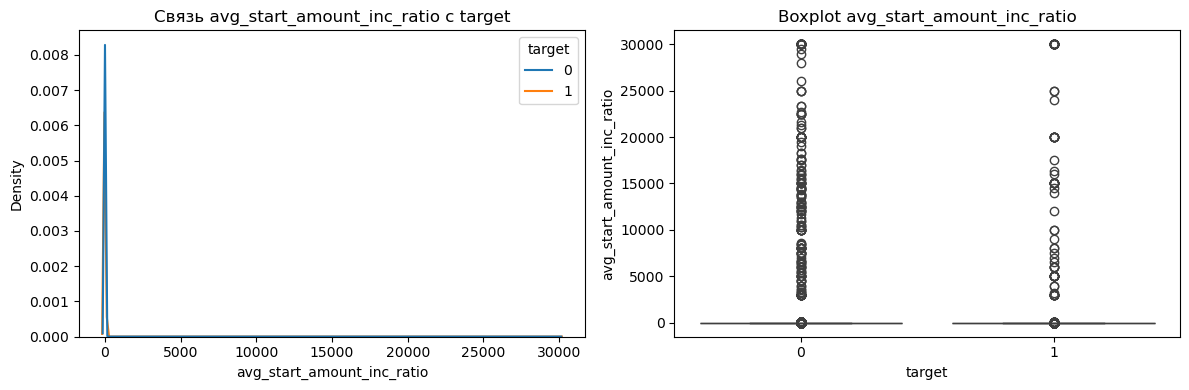

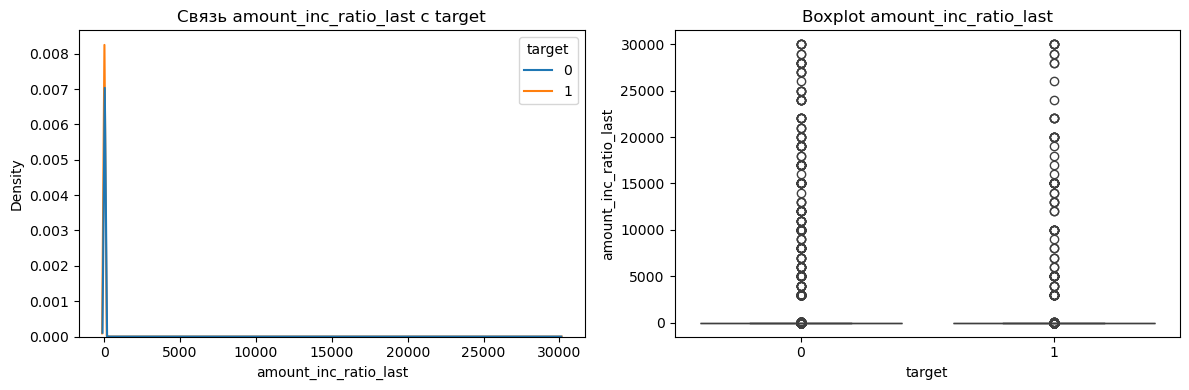

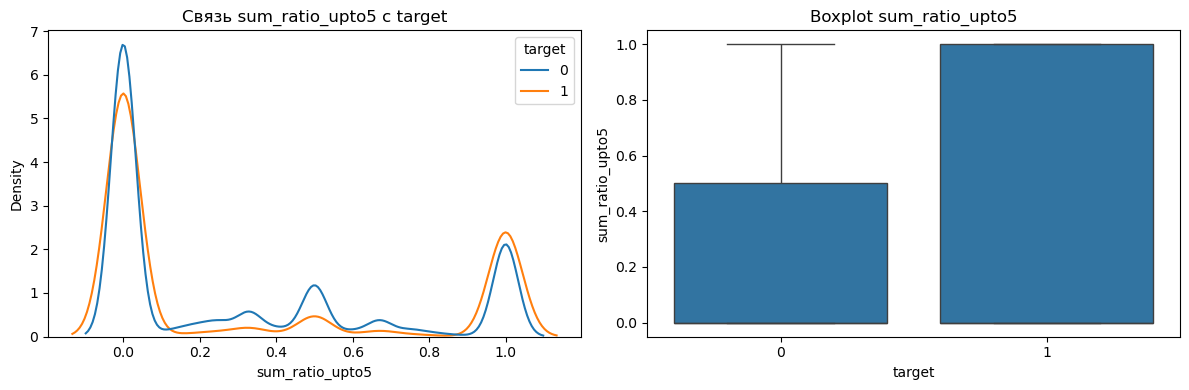

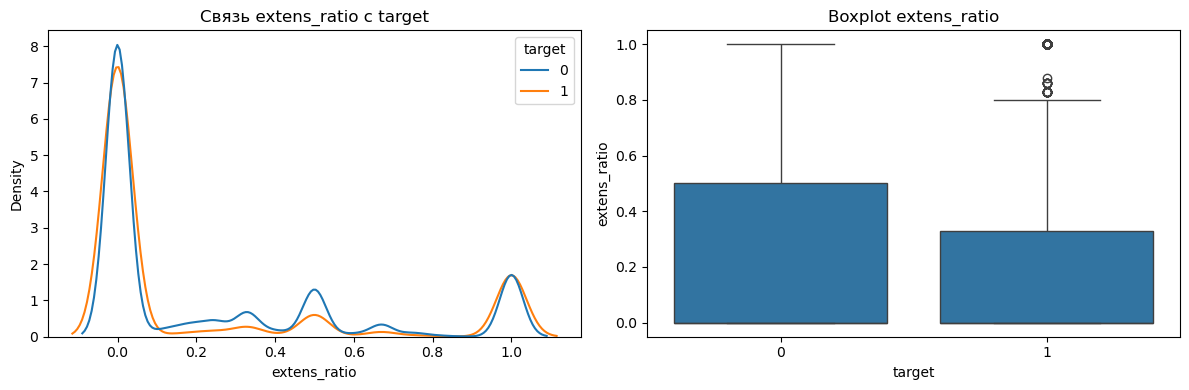

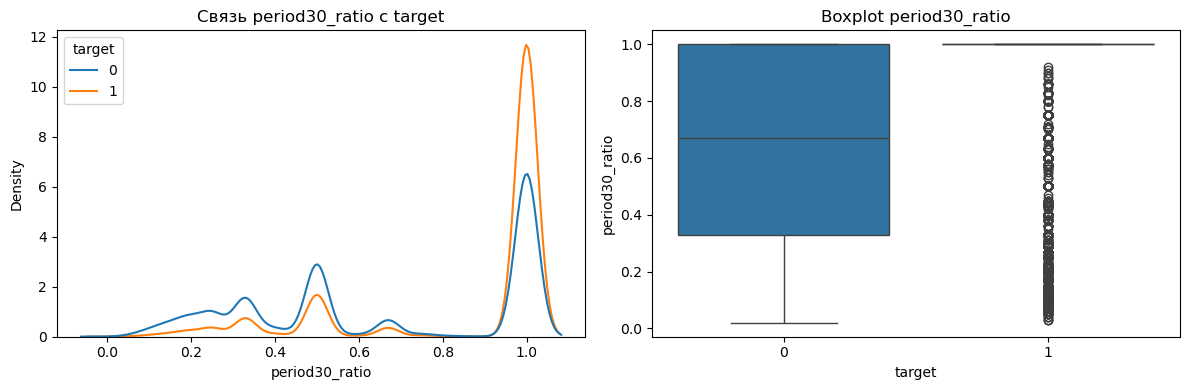

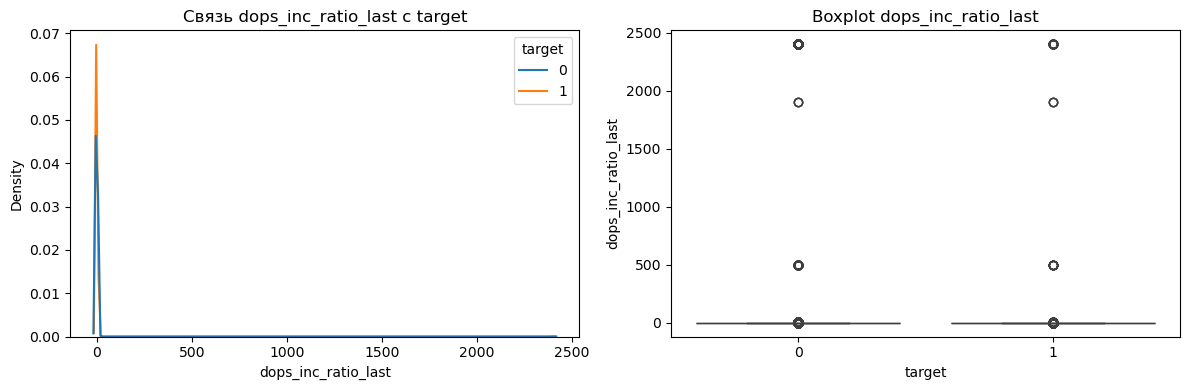

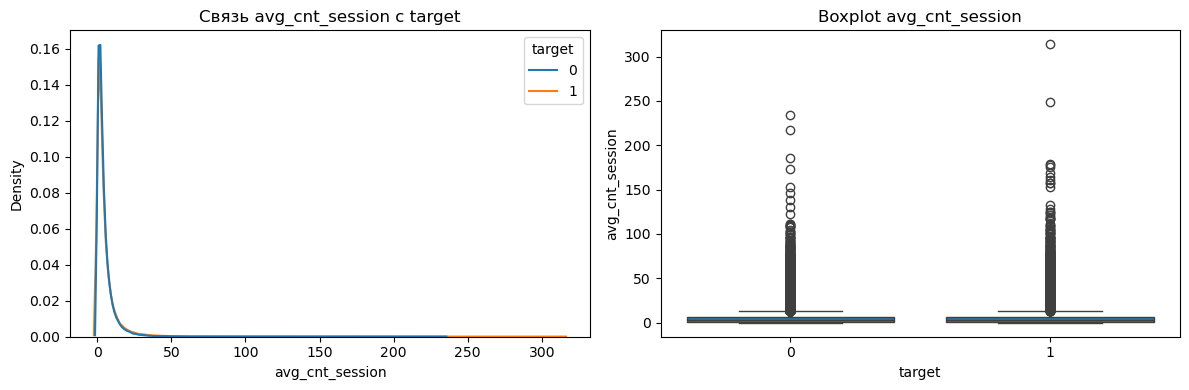

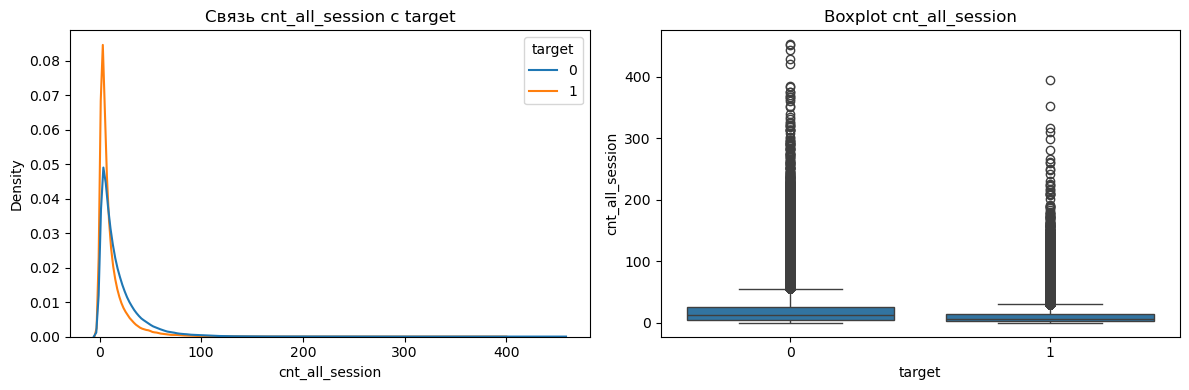

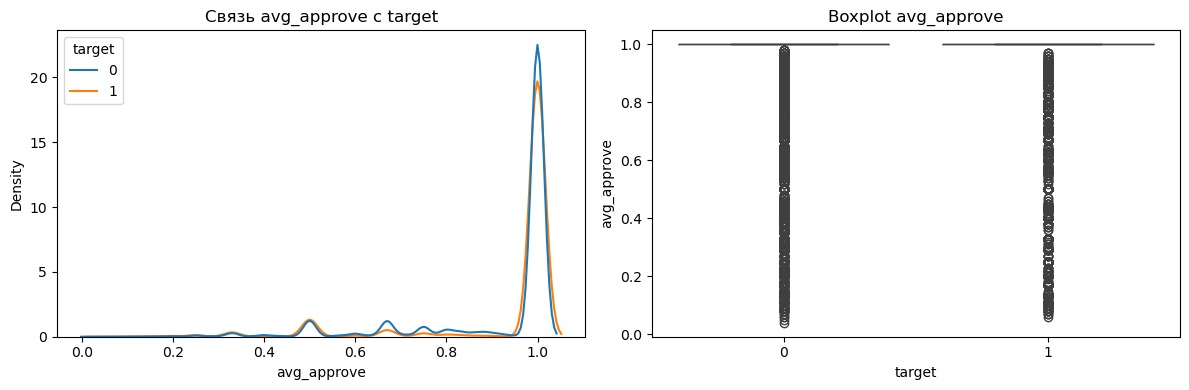

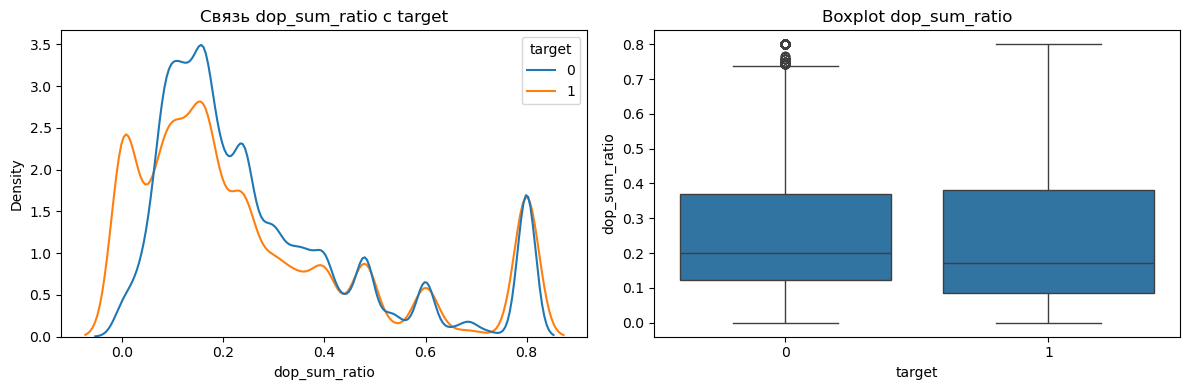

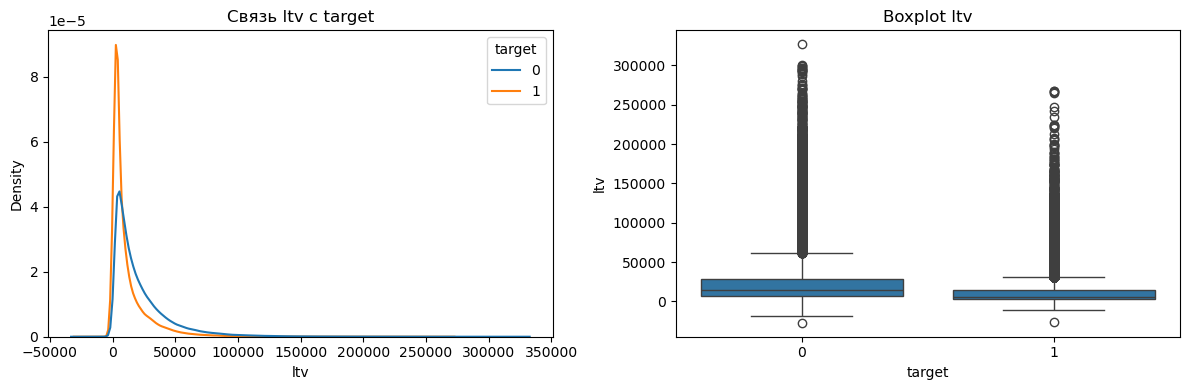

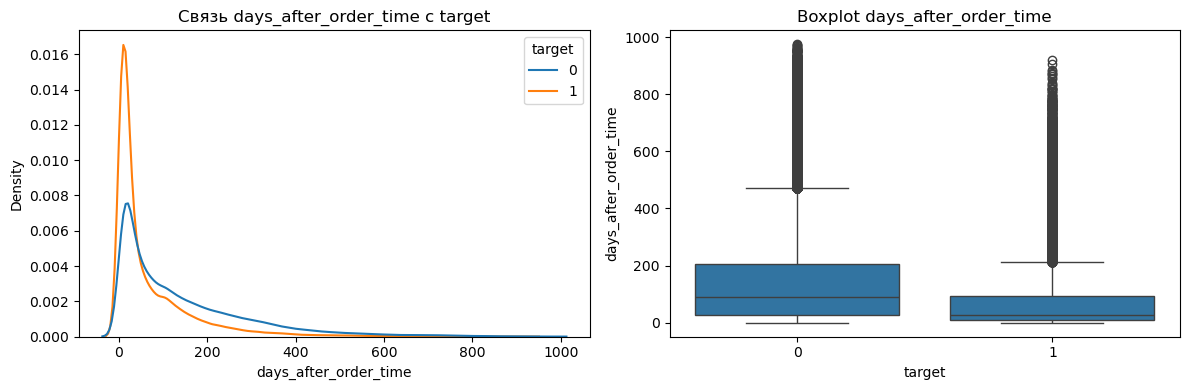

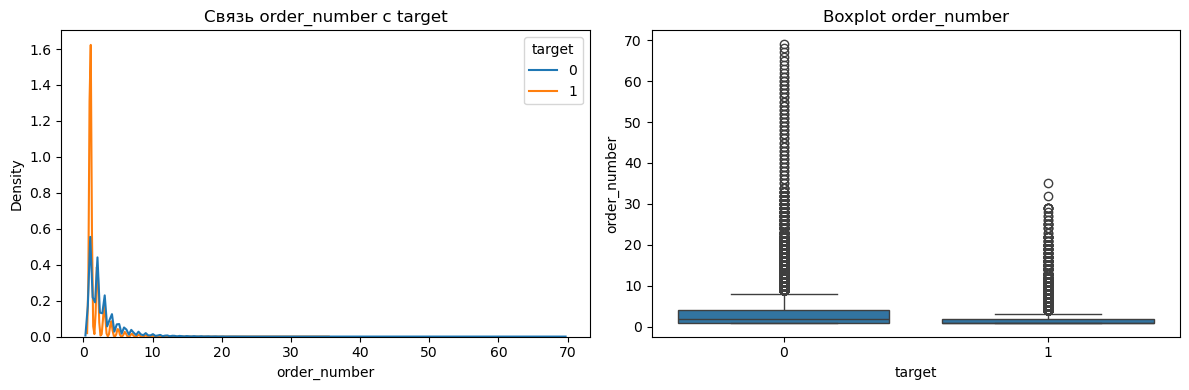

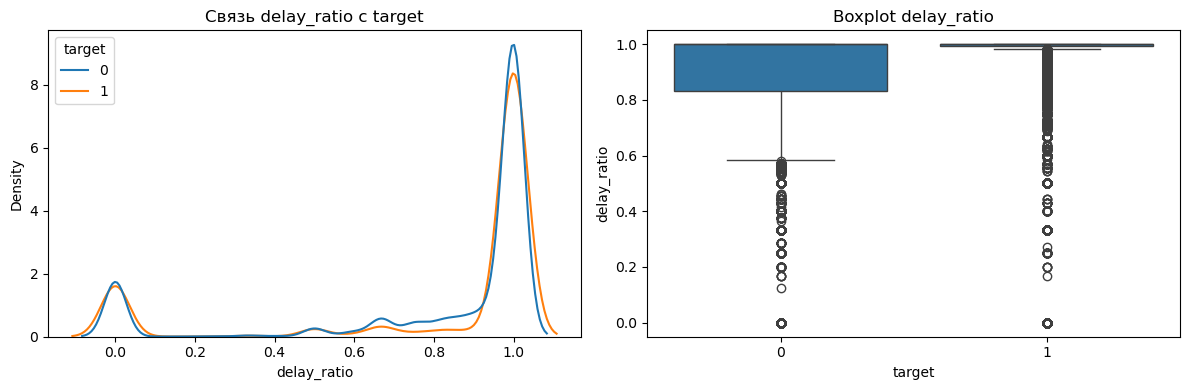

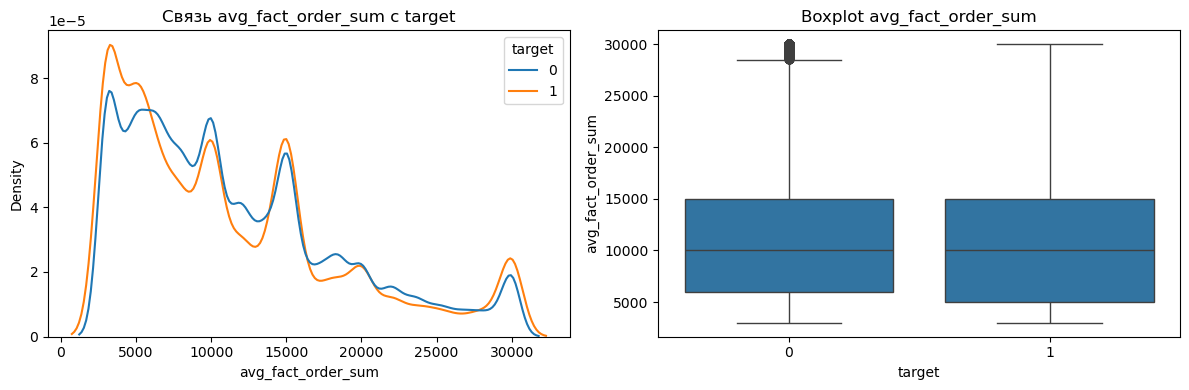

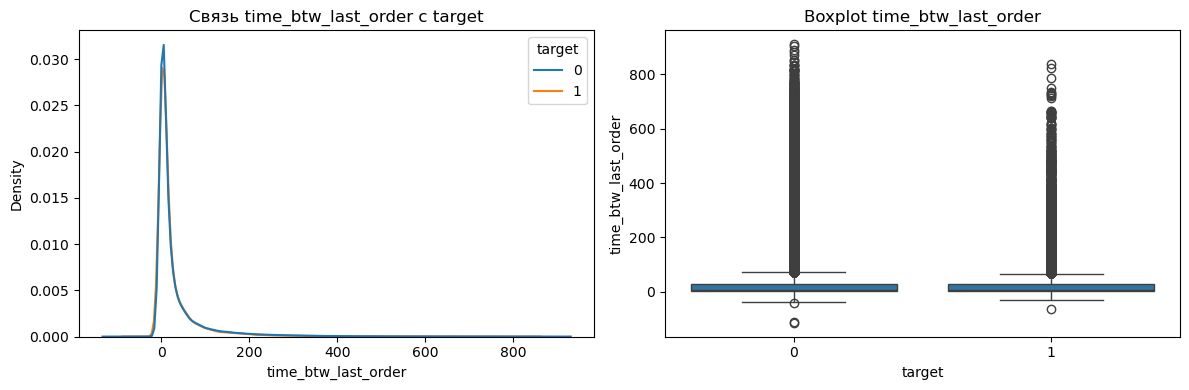

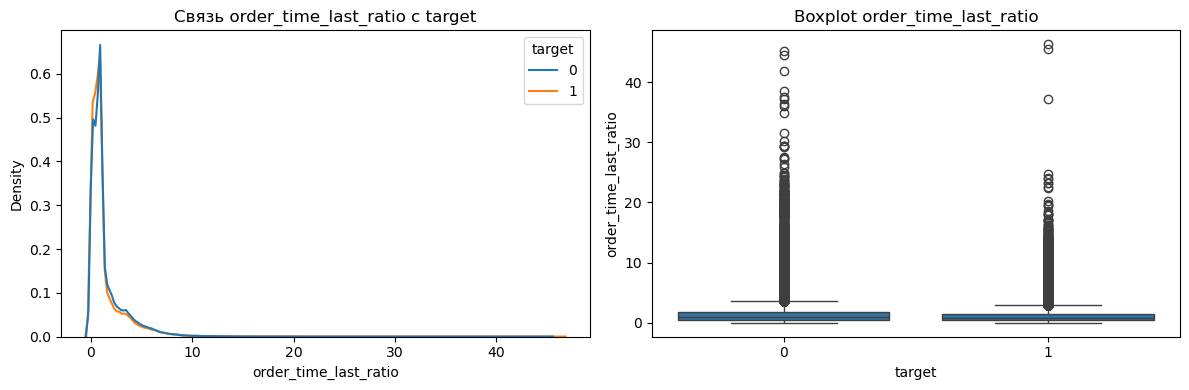

In [10]:
analyze_nums(df, num_cols)

In [11]:
def analyze_cats(df, cat_cols):
    for col in cat_cols:
        temp = df.copy()
        temp[col] = temp[col].fillna('MISSING')
        
        top_values = temp[col].value_counts().index[:20]
        temp_plot = temp[temp[col].isin(top_values)]
        
        target_rate = (
            temp_plot.groupby(col)['target']
            .mean())
        
        count_order = temp_plot[col].value_counts().index
        
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
        
        sns.countplot(
            data=temp_plot,
            x=col,
            order=count_order,
            ax=axes[0])
        
        axes[0].set_title(f'Распределение {col}')
        axes[0].tick_params(axis='x', rotation=45)
        
        sns.barplot(
            x=count_order,
            y=[target_rate.get(x, 0) for x in count_order],
            ax=axes[1])
        
        axes[1].set_title(f'{col} vs target')
        axes[1].set_ylabel('Доля target = 1')
        axes[1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()

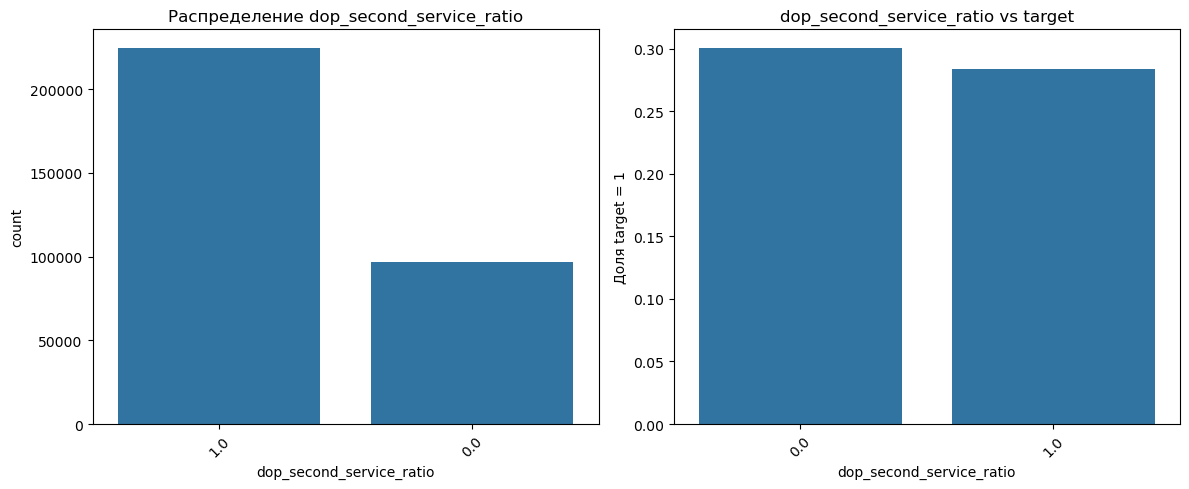

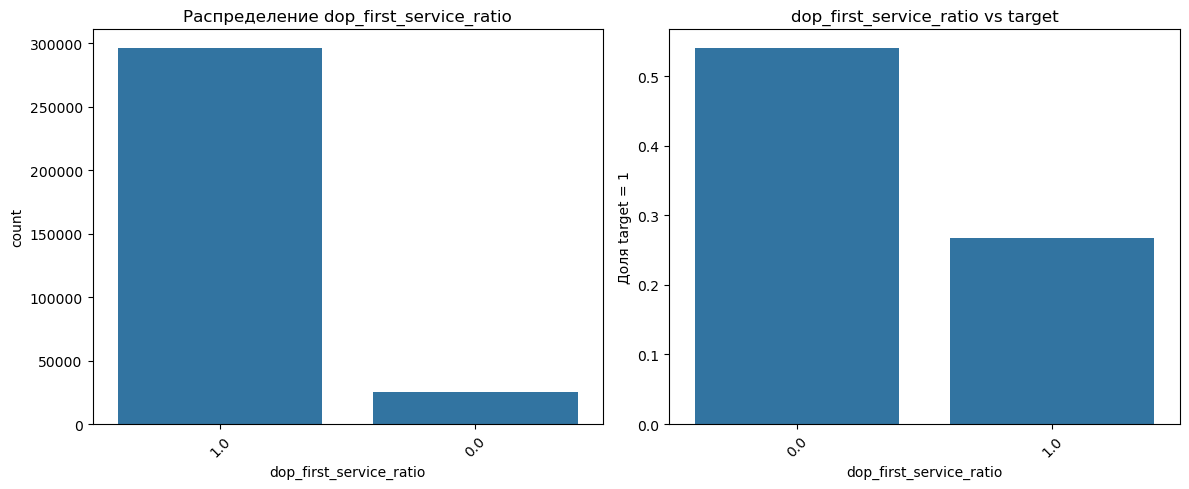

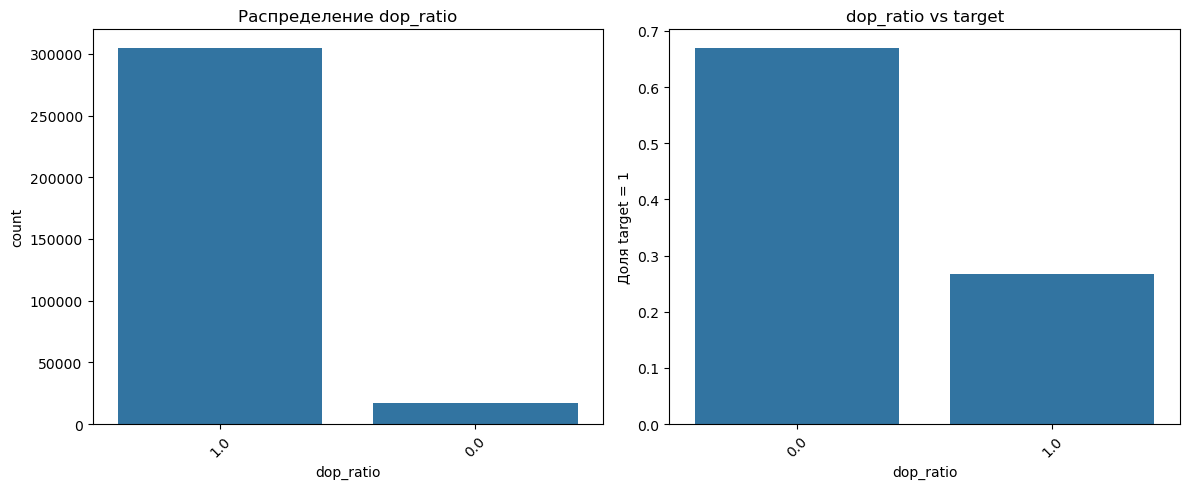

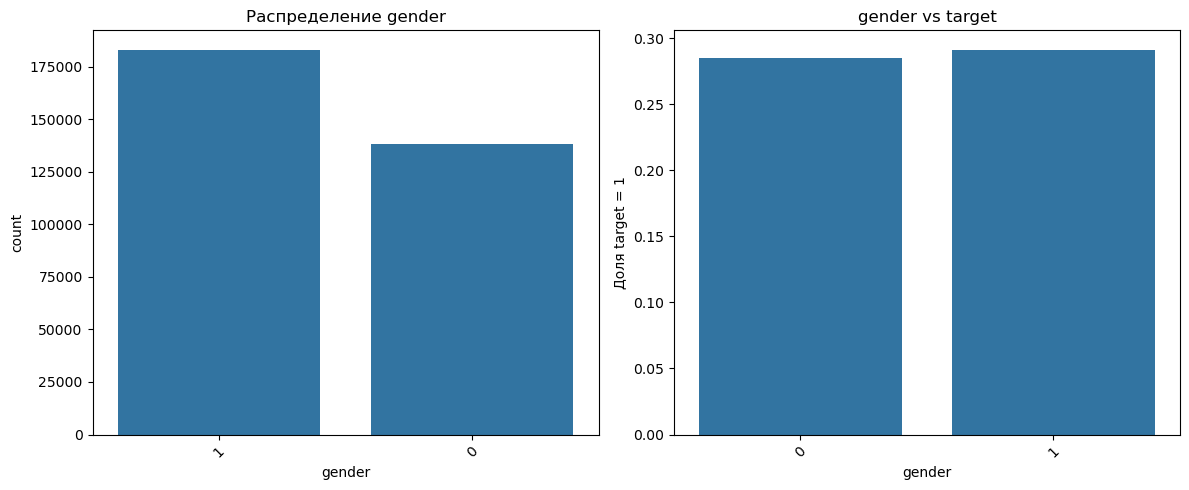

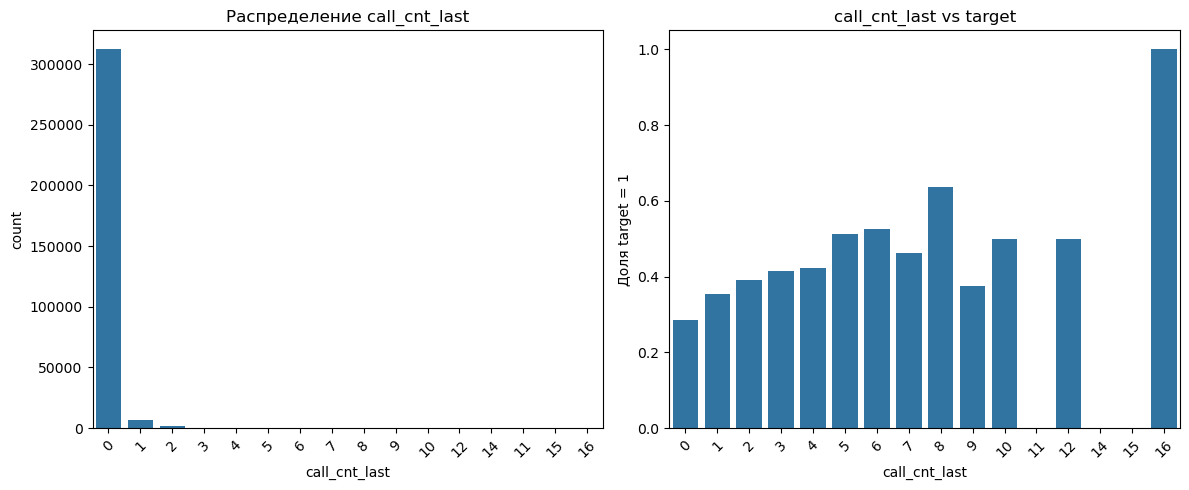

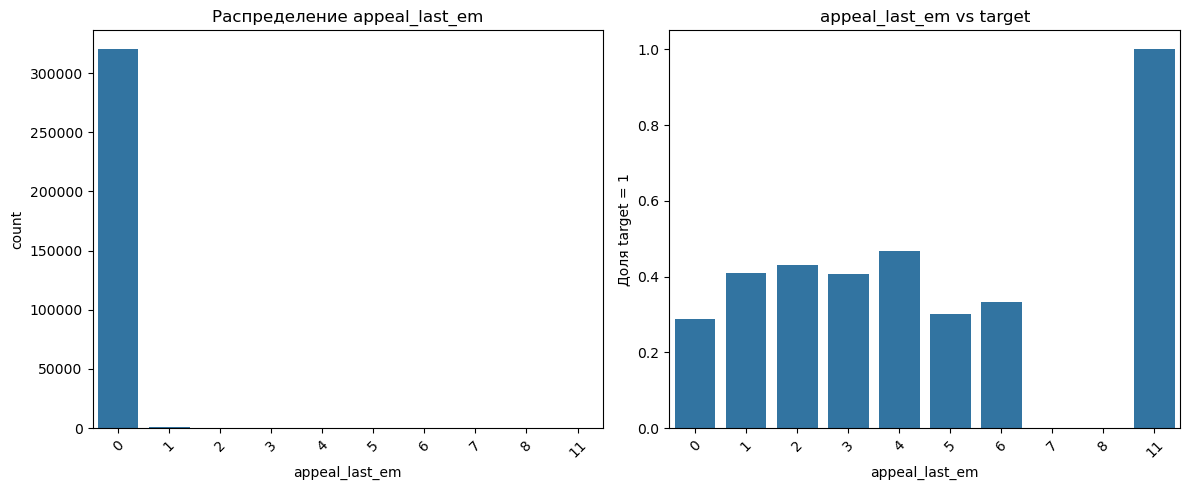

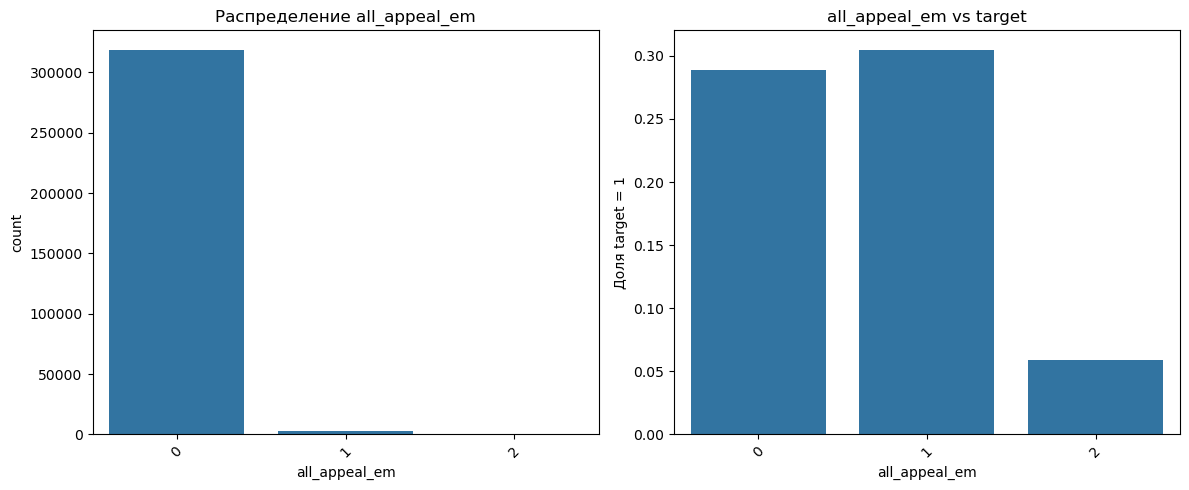

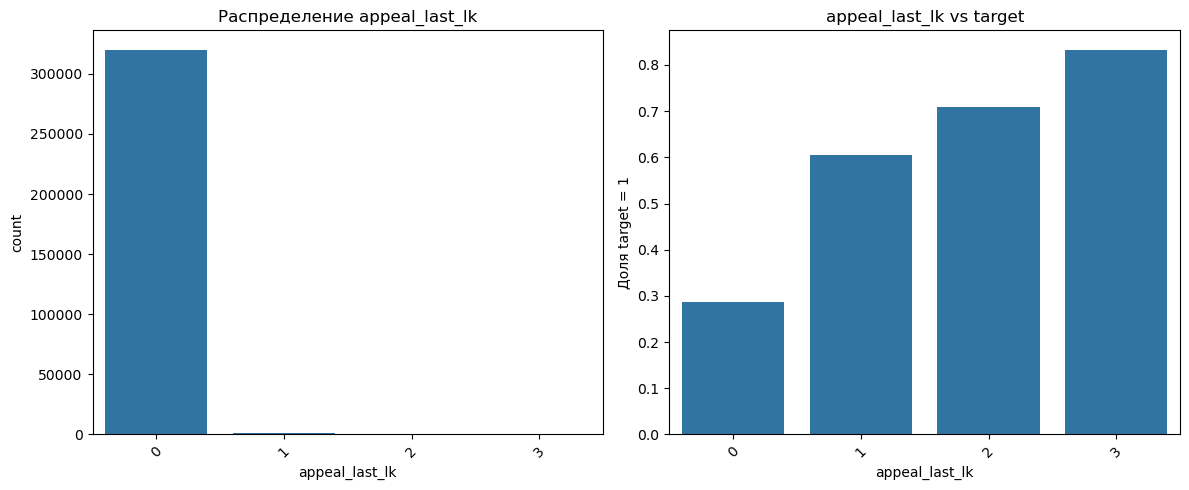

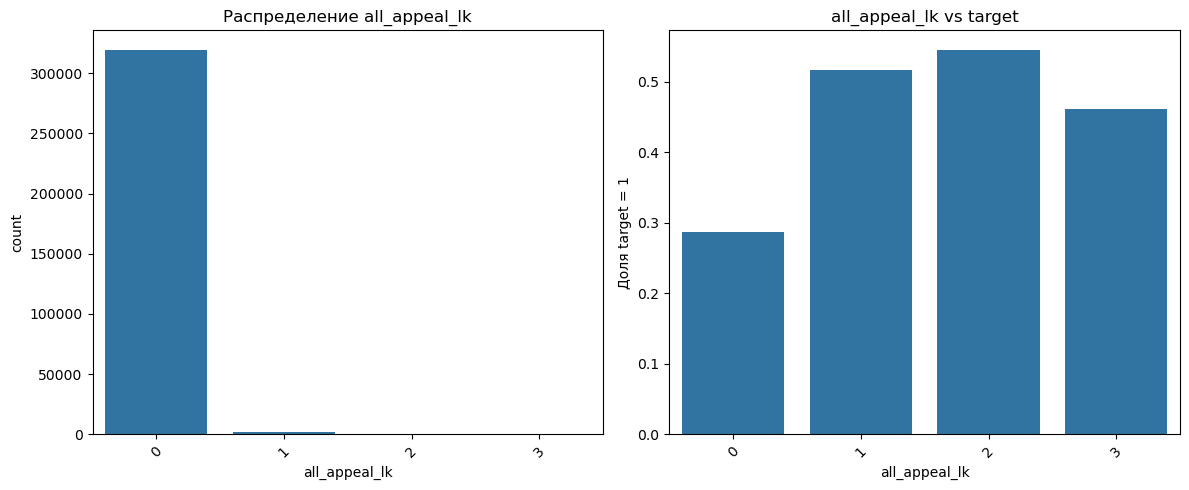

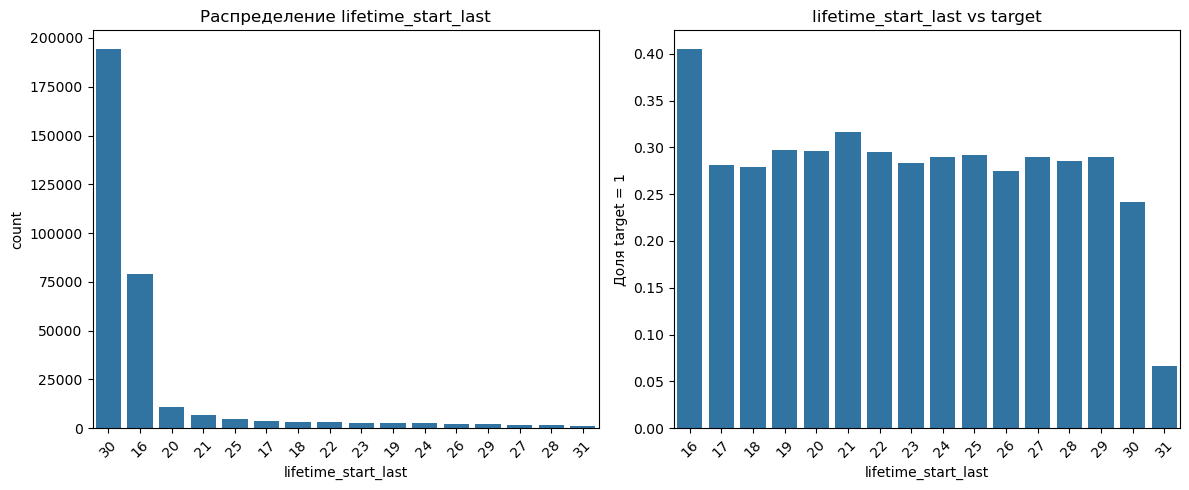

In [12]:
analyze_cats(df, cat_cols)

## Анализ перекрытия классов

In [13]:
def estimate_class_overlap(df, k=5):
    data = df.copy()

    feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in feature_cols if c not in SERVICE]

    for col in feature_cols:
        s = data[col]
        non_na = s.dropna()

        if non_na.empty:
            fill_value = -1
        else:
            min_val = non_na.min()

            if pd.api.types.is_integer_dtype(s):
                fill_value = min_val - 1
                values_set = set(non_na.values)
                while fill_value in values_set:
                    fill_value -= 1
            else:
                fill_value = min_val - 1.0
                values = non_na.values
                while np.isclose(values, fill_value).any():
                    fill_value -= 1.0

        data[col] = s.fillna(fill_value)
        
    X = StandardScaler().fit_transform(data[feature_cols].values)
    y = data['target'].values

    nn = NearestNeighbors(n_neighbors=k + 1)
    nn.fit(X)

    indices = nn.kneighbors(X, return_distance=False)[:, 1:]
    neighbor_labels = y[indices]

    kdn = (neighbor_labels != y[:, None]).mean(axis=1)

    return kdn.mean()

In [14]:
estimate_class_overlap(df)

0.3288643052245819

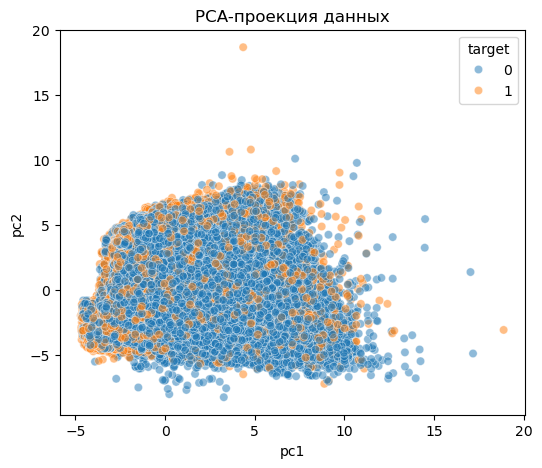

In [15]:
X = df.select_dtypes(include=[np.number]).drop(columns=SERVICE).copy()

for col in X.columns:
    s = X[col]
    non_na = s.dropna()

    if non_na.empty:
        fill_value = -1
    else:
        fill_value = non_na.min() - 1

    X[col] = s.fillna(fill_value)

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    'pc1': X_pca[:, 0],
    'pc2': X_pca[:, 1],
    'target': df['target'].values})

plt.figure(figsize=(6, 5))
sns.scatterplot(data=plot_df, x='pc1', y='pc2', hue='target', alpha=0.5)

plt.title('PCA-проекция данных')
plt.show()

## Разбиение на train/test

In [16]:
df_train_valid = df[df['oot'] == 0]
df_test = df[df['oot'] == 1]

In [17]:
df_train_valid.shape, df_train_valid['target'].mean()

((260560, 43), 0.30686598096407736)

In [18]:
df_test.shape, df_test['target'].mean()

((60882, 43), 0.21066982030813705)

In [19]:
x_train_valid = df_train_valid.drop(columns=['demand', 'oot', 'target'])
y_train_valid = df_train_valid['target']
x_test = df_test.drop(columns=['demand', 'oot', 'target'])
y_test = df_test['target']

## Обучение моделей на кросс-валидации с доверительными интервалами

In [20]:
def bootstrap_ci(y_true, y_score, y_pred, n_bootstrap=1000, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(y_true)

    metrics = {
        'roc_auc': [],
        'pr_auc': [],
        'precision': [],
        'recall': [],
        'f1': []}

    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    y_pred = np.asarray(y_pred)

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)

        y_true_b = y_true[idx]
        y_score_b = y_score[idx]
        y_pred_b = y_pred[idx]

        if len(np.unique(y_true_b)) < 2:
            continue

        metrics['roc_auc'].append(roc_auc_score(y_true_b, y_score_b))
        metrics['pr_auc'].append(average_precision_score(y_true_b, y_score_b))
        metrics['precision'].append(precision_score(y_true_b, y_pred_b, zero_division=0))
        metrics['recall'].append(recall_score(y_true_b, y_pred_b, zero_division=0))
        metrics['f1'].append(f1_score(y_true_b, y_pred_b, zero_division=0))

    rows = []
    for metric_name, values in metrics.items():
        values = np.array(values)
        rows.append({
            'metric': metric_name,
            'mean': values.mean(),
            'ci_lower_95': np.percentile(values, 2.5),
            'ci_upper_95': np.percentile(values, 97.5)})

    return pd.DataFrame(rows)

In [21]:
def evaluate_model(
    X,
    y,
    model,
    n_splits=5,
    threshold=0.5,
    n_bootstrap=1000,
    needs_scaling=False,
    needs_imputation=True,
    imputer_fill_value=-115):
    
    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE)

    steps = []

    if needs_imputation:
        steps.append(
            ('imputer', SimpleImputer(strategy='constant', fill_value=imputer_fill_value)))

    if needs_scaling:
        steps.append(('scaler', StandardScaler()))

    steps.append(('model', clone(model)))
    pipeline = Pipeline(steps)

    y_score = cross_val_predict(
        pipeline,
        X,
        y,
        cv=cv,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]

    y_pred = (y_score >= threshold).astype(int)

    point_metrics = pd.DataFrame({
        'metric': ['roc_auc', 'pr_auc', 'precision', 'recall', 'f1'],
        'value': [
            roc_auc_score(y, y_score),
            average_precision_score(y, y_score),
            precision_score(y, y_pred, zero_division=0),
            recall_score(y, y_pred, zero_division=0),
            f1_score(y, y_pred, zero_division=0)]})

    ci_metrics = bootstrap_ci(
        y_true=y.values if hasattr(y, 'values') else y,
        y_score=y_score,
        y_pred=y_pred,
        n_bootstrap=n_bootstrap,
        random_state=RANDOM_STATE)

    result = point_metrics.merge(ci_metrics, on='metric', how='left')
    result = result[['metric', 'value', 'ci_lower_95', 'ci_upper_95']]

    predictions = pd.DataFrame({
        'y_true': y.values if hasattr(y, 'values') else y,
        'y_score': y_score,
        'y_pred': y_pred})

    return result, predictions

def make_logreg(class_weight=None):
    return LogisticRegression(
        class_weight=class_weight,
        max_iter=2000,
        solver='lbfgs',
        random_state=RANDOM_STATE)

def make_random_forest(class_weight='balanced'):
    return RandomForestClassifier(
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1)

def make_xgboost(y, auto_balance=True):
    if auto_balance:
        n_pos = (y == 1).sum()
        n_neg = (y == 0).sum()
        scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0
    else:
        scale_pos_weight = 1.0

    return XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='logloss')

def make_catboost():
    return CatBoostClassifier(
        auto_class_weights='Balanced',
        random_seed=RANDOM_STATE,
        verbose=0)

In [22]:
%%time
models = {
    'logreg': {
        'model': make_logreg(class_weight=None),
        'needs_scaling': True,
        'needs_imputation': True
    },
    'logreg_balanced': {
        'model': make_logreg(class_weight='balanced'),
        'needs_scaling': True,
        'needs_imputation': True
    },
    'random_forest': {
        'model': make_random_forest(class_weight='balanced'),
        'needs_scaling': False,
        'needs_imputation': True
    },
    'xgboost': {
        'model': make_xgboost(y=y_train_valid, auto_balance=True),
        'needs_scaling': False,
        'needs_imputation': False
    },
    'catboost': {
        'model': make_catboost(),
        'needs_scaling': False,
        'needs_imputation': False}}

all_results = {}
all_predictions = {}

for model_name, cfg in models.items():
    result, pred = evaluate_model(
        X=x_train_valid,
        y=y_train_valid,
        model=cfg['model'],
        needs_scaling=cfg['needs_scaling'],
        needs_imputation=cfg['needs_imputation'])

    all_results[model_name] = result
    all_predictions[model_name] = pred

    print(f'\n{model_name}')
    print(result)


logreg
      metric  value  ci_lower_95  ci_upper_95
0    roc_auc  0.744        0.742        0.746
1     pr_auc  0.591        0.588        0.594
2  precision  0.672        0.668        0.677
3     recall  0.297        0.294        0.300
4         f1  0.412        0.408        0.415

logreg_balanced
      metric  value  ci_lower_95  ci_upper_95
0    roc_auc  0.744        0.742        0.746
1     pr_auc  0.588        0.585        0.592
2  precision  0.474        0.471        0.476
3     recall  0.704        0.701        0.707
4         f1  0.566        0.564        0.569

random_forest
      metric  value  ci_lower_95  ci_upper_95
0    roc_auc  0.782        0.780        0.784
1     pr_auc  0.647        0.644        0.650
2  precision  0.695        0.691        0.699
3     recall  0.366        0.363        0.369
4         f1  0.480        0.476        0.483

xgboost
      metric  value  ci_lower_95  ci_upper_95
0    roc_auc  0.810        0.808        0.811
1     pr_auc  0.685        0.68

In [23]:
comparison = pd.concat(
    [
        res.assign(model=model_name)
        for model_name, res in all_results.items()
    ],
    ignore_index=True
)[['model', 'metric', 'value', 'ci_lower_95', 'ci_upper_95']]

print(comparison)

              model     metric  value  ci_lower_95  ci_upper_95
0            logreg    roc_auc  0.744        0.742        0.746
1            logreg     pr_auc  0.591        0.588        0.594
2            logreg  precision  0.672        0.668        0.677
3            logreg     recall  0.297        0.294        0.300
4            logreg         f1  0.412        0.408        0.415
5   logreg_balanced    roc_auc  0.744        0.742        0.746
6   logreg_balanced     pr_auc  0.588        0.585        0.592
7   logreg_balanced  precision  0.474        0.471        0.476
8   logreg_balanced     recall  0.704        0.701        0.707
9   logreg_balanced         f1  0.566        0.564        0.569
10    random_forest    roc_auc  0.782        0.780        0.784
11    random_forest     pr_auc  0.647        0.644        0.650
12    random_forest  precision  0.695        0.691        0.699
13    random_forest     recall  0.366        0.363        0.369
14    random_forest         f1  0.480   

In [24]:
best_model_name = (
    comparison[comparison['metric'] == 'roc_auc']
    .sort_values('value', ascending=False)
    .iloc[0]['model']
)

print('Лучшая модель по ROC_AUC:', best_model_name)

Лучшая модель по ROC_AUC: catboost


In [25]:
roc_auc_table = (
    comparison[comparison['metric'] == 'roc_auc']
    [['model', 'value', 'ci_lower_95', 'ci_upper_95']]
    .rename(columns={
        'value': 'roc_auc',
        'ci_lower_95': 'ci_lower_95',
        'ci_upper_95': 'ci_upper_95'})
    .sort_values('roc_auc', ascending=False)
    .reset_index(drop=True))

roc_auc_table

,model,roc_auc,ci_lower_95,ci_upper_95
0,catboost,0.816,0.814,0.818
1,xgboost,0.810,0.808,0.811
2,random_forest,0.782,0.780,0.784
3,logreg_balanced,0.744,0.742,0.746
4,logreg,0.744,0.742,0.746


## Проверка стат. значимости лучшего результата

In [26]:
def compute_midrank(x):
   
    x = np.asarray(x)
    J = np.argsort(x)
    Z = x[J]
    N = len(x)

    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j

    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2

def fast_delong(predictions_sorted_transposed, label_1_count):
    
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m

    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]

    k = predictions_sorted_transposed.shape[0]

    tx = np.empty((k, m), dtype=float)
    ty = np.empty((k, n), dtype=float)
    tz = np.empty((k, m + n), dtype=float)

    for r in range(k):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])

    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / (2.0 * n)

    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m

    sx = np.cov(v01)
    sy = np.cov(v10)

    delongcov = sx / m + sy / n
    return aucs, delongcov

def calc_pvalue(aucs, sigma):
    
    diff = aucs[0] - aucs[1]
    var = sigma[0, 0] + sigma[1, 1] - 2 * sigma[0, 1]

    z = np.abs(diff) / np.sqrt(var)
    p_value = 2 * stats.norm.sf(z)
    return z, p_value

def delong_roc_test(y_true, y_score_1, y_score_2):
    
    y_true = np.asarray(y_true).astype(int)
    y_score_1 = np.asarray(y_score_1, dtype=float)
    y_score_2 = np.asarray(y_score_2, dtype=float)

    if not (len(y_true) == len(y_score_1) == len(y_score_2)):
        raise ValueError('y_true, y_score_1, y_score_2 должны быть одинаковой длины!')

    order = np.argsort(-y_true)
    y_true_sorted = y_true[order]
    preds_sorted = np.vstack([y_score_1[order], y_score_2[order]])

    label_1_count = int(y_true_sorted.sum())

    aucs, delongcov = fast_delong(preds_sorted, label_1_count)
    z_stat, p_value = calc_pvalue(aucs, delongcov)

    return {
        'auc_1': aucs[0],
        'auc_2': aucs[1],
        'auc_diff': aucs[0] - aucs[1],
        'z_stat': z_stat,
        'p_value': p_value}

In [27]:
pred_xgb = all_predictions['xgboost'].copy()
pred_cat = all_predictions['catboost'].copy()

auc_xgb = roc_auc_score(pred_xgb['y_true'], pred_xgb['y_score'])
auc_cat = roc_auc_score(pred_cat['y_true'], pred_cat['y_score'])

result_delong = delong_roc_test(
    y_true=pred_xgb['y_true'].values,
    y_score_1=pred_xgb['y_score'].values,
    y_score_2=pred_cat['y_score'].values)

print(f'ROC-AUC XGBoost    : {auc_xgb:.6f}')
print(f'ROC-AUC CatBoost   : {auc_cat:.6f}')
print(f'Разница (XGB - Cat): {result_delong['auc_diff']:.6f}')
print(f'z-stat             : {result_delong['z_stat']:.6f}')
print(f'p-value            : {result_delong['p_value']:.6g}')

alpha = 0.05

print('Результаты DeLong теста:')
if result_delong['p_value'] < alpha:
    print('Различие ROC-AUC моделей статистически значимо.')
else:
    print('Нет статистически значимого различия ROC-AUC моделей.')

ROC-AUC XGBoost    : 0.809757
ROC-AUC CatBoost   : 0.815991
Разница (XGB - Cat): -0.006233
z-stat             : 21.255271
p-value            : 2.94656e-100
Результаты DeLong теста:
Различие ROC-AUC моделей статистически значимо.


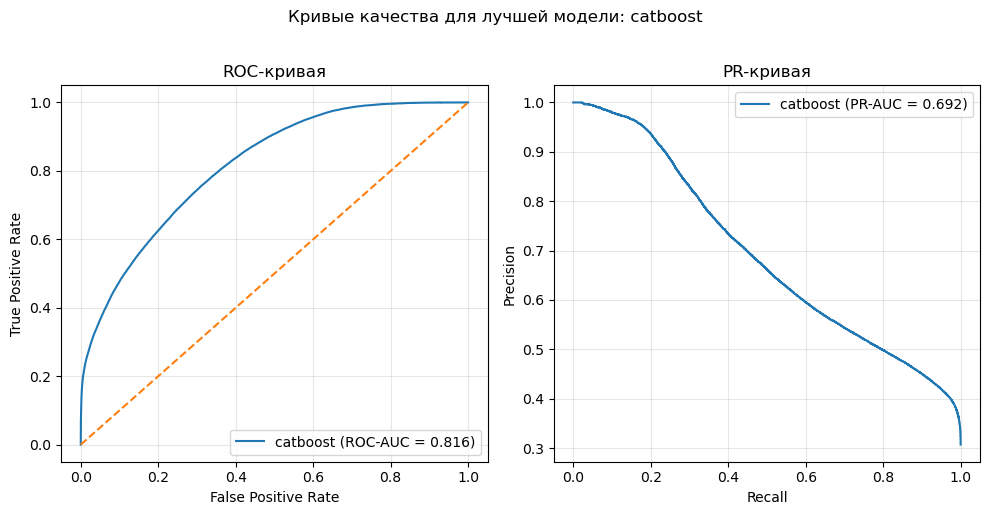

In [28]:
pred_df = all_predictions[best_model_name]

y_true = pred_df['y_true'].values
y_score = pred_df['y_score'].values

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = roc_auc_score(y_true, y_score)

precision, recall, _ = precision_recall_curve(y_true, y_score)
pr_auc = average_precision_score(y_true, y_score)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# график ROC-AUC
axes[0].plot(fpr, tpr, label=f'{best_model_name} (ROC-AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC-кривая')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# график PR-AUC
axes[1].plot(recall, precision, label=f'{best_model_name} (PR-AUC = {pr_auc:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR-кривая')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Кривые качества для лучшей модели: {best_model_name}', y=1.02)
plt.tight_layout()
plt.show()

## Проверка калиброванности вероятностей

In [29]:
# хелперы для дальнейших функций/классов

def _safe_index(X, idx):
    if isinstance(X, (pd.DataFrame, pd.Series)):
        return X.iloc[idx]
    return X[idx]

def _to_numpy_1d(y):
    if isinstance(y, pd.Series):
        return y.values
    if isinstance(y, pd.DataFrame):
        return y.iloc[:, 0].values
    return np.asarray(y).ravel()

def _validate_binary_target(y):
    y_np = _to_numpy_1d(y)
    unique_values = np.unique(y_np)

def clone_estimator(estimator):
    return deepcopy(estimator)

In [30]:
# классы калибраторов

class PlattCalibrator:
    def __init__(self, C=1e6, max_iter=1000):
        self.C = C
        self.max_iter = max_iter
        self.model = LogisticRegression(
            solver='lbfgs',
            C=self.C,
            max_iter=self.max_iter)

    def fit(self, p_raw, y):
        x = np.asarray(p_raw).reshape(-1, 1)
        y = np.asarray(y)
        self.model.fit(x, y)
        return self

    def predict_proba(self, p_raw):
        x = np.asarray(p_raw).reshape(-1, 1)
        return self.model.predict_proba(x)[:, 1]

class IsotonicCalibrator:
    def __init__(self):
        self.model = IsotonicRegression(out_of_bounds='clip')

    def fit(self, p_raw, y):
        x = np.asarray(p_raw)
        y = np.asarray(y)
        self.model.fit(x, y)
        return self

    def predict_proba(self, p_raw):
        x = np.asarray(p_raw)
        return self.model.predict(x)

def clone_calibrator(calibrator):
    return deepcopy(calibrator)

In [31]:
def get_positive_proba(model, X):
    p = model.predict_proba(X)
    return p[:, 1]

def get_crossfitted_oof_probabilities(
    estimator,
    X,
    y,
    outer_cv=None,
    inner_cv=None,
    calibrators=None,
    fit_params=None,
    verbose=True):

    if outer_cv is None:
        outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    if inner_cv is None:
        inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=43)

    if calibrators is None:
        calibrators = {
            'platt': PlattCalibrator(),
            'isotonic': IsotonicCalibrator()}

    if fit_params is None:
        fit_params = {}

    _validate_binary_target(y)

    y_np = _to_numpy_1d(y)
    n = len(y_np)

    p_oof_raw = np.zeros(n, dtype=float)
    p_oof_calibrated = {
        name: np.zeros(n, dtype=float)
        for name in calibrators}

    for fold_num, (outer_train_idx, outer_valid_idx) in enumerate(
        outer_cv.split(np.zeros(n), y_np), start=1):

        X_outer_train = _safe_index(X, outer_train_idx)
        y_outer_train = _to_numpy_1d(_safe_index(y, outer_train_idx))
        X_outer_valid = _safe_index(X, outer_valid_idx)

        inner_oof_proba = np.zeros(len(outer_train_idx), dtype=float)

        for inner_train_rel, inner_valid_rel in inner_cv.split(
            np.zeros(len(y_outer_train)), y_outer_train):
            
            X_inner_train = _safe_index(X_outer_train, inner_train_rel)
            y_inner_train = y_outer_train[inner_train_rel]
            X_inner_valid = _safe_index(X_outer_train, inner_valid_rel)

            inner_model = clone_estimator(estimator)
            inner_model.fit(X_inner_train, y_inner_train, **fit_params)

            inner_oof_proba[inner_valid_rel] = get_positive_proba(
                inner_model, X_inner_valid)

        outer_model = clone_estimator(estimator)
        outer_model.fit(X_outer_train, y_outer_train, **fit_params)

        outer_valid_raw_proba = get_positive_proba(outer_model, X_outer_valid)
        p_oof_raw[outer_valid_idx] = outer_valid_raw_proba

        for cal_name, cal_proto in calibrators.items():
            calibrator = clone_calibrator(cal_proto)
            calibrator.fit(inner_oof_proba, y_outer_train)
            p_oof_calibrated[cal_name][outer_valid_idx] = calibrator.predict_proba(
                outer_valid_raw_proba)

    return p_oof_raw, p_oof_calibrated

In [32]:
def get_calibration_metrics(y_true, y_prob):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    eps = 1e-15
    y_prob = np.clip(y_prob, eps, 1 - eps)

    return {
        'roc_auc': roc_auc_score(y_true, y_prob),
        'brier': brier_score_loss(y_true, y_prob),
        'logloss': log_loss(y_true, y_prob)}

def build_calibration_table(y_true, y_prob, n_bins=10, strategy='quantile'):
    frac_pos, mean_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=n_bins,
        strategy=strategy)

    calib_df = pd.DataFrame({
        'mean_predicted_proba': mean_pred,
        'observed_positive_rate': frac_pos})
    
    calib_df['abs_gap'] = np.abs(
        calib_df['mean_predicted_proba'] - calib_df['observed_positive_rate'])
    
    return calib_df

def plot_calibration_curve_from_table(calib_df, label):
    plt.figure(figsize=(5, 5))
    plt.plot([0, 1], [0, 1], '--', label='Идеальная калибровка')
    plt.plot(
        calib_df['mean_predicted_proba'],
        calib_df['observed_positive_rate'],
        marker='o',
        label=label
    )
    plt.xlabel('Средняя предсказанная вероятность')
    plt.ylabel('Доля положительного класса')
    plt.title(f'Калибровочная кривая - {label}')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [33]:
def evaluate_probabilities(
    y_true,
    y_prob,
    label='model',
    n_bins=10,
    strategy='quantile',
    show_plot=True,
    print_report=True):
    
    metrics = get_calibration_metrics(y_true, y_prob)
    calib_df = build_calibration_table(
        y_true=y_true,
        y_prob=y_prob,
        n_bins=n_bins,
        strategy=strategy)

    if show_plot:
        plot_calibration_curve_from_table(calib_df, label)

    if print_report:
        print(f'Model     : {label}')
        print(f'ROC-AUC   : {metrics["roc_auc"]:.6f}')
        print(f'Brier     : {metrics["brier"]:.6f}')
        print(f'LogLoss   : {metrics["logloss"]:.6f}')
        print(f'Mean abs calibration gap: {calib_df["abs_gap"].mean():.6f}')
        print()
        print(calib_df)

    return {
        'label': label,
        'metrics': metrics,
        'calibration_table': calib_df}

In [34]:
def compare_probability_versions(
    y_true,
    prob_dict,
    n_bins=10,
    strategy='quantile',
    plot_each=False,
    print_tables=False):
    
    summary_rows = []
    calibration_tables = {}

    for label, prob in prob_dict.items():
        result = evaluate_probabilities(
            y_true=y_true,
            y_prob=prob,
            label=label,
            n_bins=n_bins,
            strategy=strategy,
            show_plot=plot_each,
            print_report=False)

        metrics = result['metrics']
        calib_df = result['calibration_table']

        summary_rows.append({
            'version': label,
            'roc_auc': metrics['roc_auc'],
            'brier': metrics['brier'],
            'logloss': metrics['logloss'],
            'mean_abs_gap': calib_df['abs_gap'].mean(),
            'max_abs_gap': calib_df['abs_gap'].max()})

        calibration_tables[label] = calib_df

        if print_tables:
            print(f'\n=== {label} ===')
            print(calib_df)

    comparison_df = (
        pd.DataFrame(summary_rows)
        .sort_values(by=['brier', 'logloss'], ascending=[True, True])
        .reset_index(drop=True))

    return comparison_df, calibration_tables

In [35]:
def interpret_calibration(calib_df):
    mean_gap = calib_df['abs_gap'].mean()
    max_gap = calib_df['abs_gap'].max()

    if mean_gap < 0.03 and max_gap < 0.07:
        print('Калибровка достаточно хорошая.')
    elif mean_gap < 0.05 and max_gap < 0.10:
        print('Калибровка приемлемая.')
    else:
        print('Калибровка нарушена.')
        print('Если линия ниже идеальной диагонали, модель переоценивает вероятности.')
        print('Если линия ниже идеальной диагонали: модель недооценивает вероятности.')

In [36]:
# подбор порога после калибровки
def find_best_threshold(y_true, y_score, metric='f1', thresholds=None):
    y_true = np.asarray(y_true)

    if thresholds is None:
        thresholds = np.arange(0.01, 1.00, 0.01)

    rows = []

    for thr in thresholds:
        y_pred = (y_score >= thr).astype(int)

        if metric == 'f1':
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == 'mcc':
            score = matthews_corrcoef(y_true, y_pred)
        else:
            raise ValueError("metric must be 'f1' or 'mcc'")

        rows.append({
            'threshold': thr,
            'metric_value': score,
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'mcc': matthews_corrcoef(y_true, y_pred)})

    threshold_table = (
        pd.DataFrame(rows)
        .sort_values(by='metric_value', ascending=False)
        .reset_index(drop=True))

    best_threshold = threshold_table.loc[0, 'threshold']
    return best_threshold, threshold_table

In [37]:
def fit_final_model_and_calibrator(
    estimator,
    X_train,
    y_train,
    selected_version,
    p_oof_raw_train=None,
    fit_params=None,
    final_calibration_mode='strict_oof'):

    if fit_params is None:
        fit_params = {}

    y_train_np = _to_numpy_1d(y_train)
    _validate_binary_target(y_train_np)

    final_model = clone_estimator(estimator)
    final_model.fit(X_train, y_train_np, **fit_params)

    if selected_version == 'raw':
        final_calibrator = None
        return final_model, final_calibrator

    if selected_version == 'platt':
        final_calibrator = PlattCalibrator()
    elif selected_version == 'isotonic':
        final_calibrator = IsotonicCalibrator()
    else:
        raise ValueError("Выбранный калибратор должен быть 'raw', 'platt' или 'isotonic'!")

    if final_calibration_mode == 'strict_oof':
        if p_oof_raw_train is None:
            raise ValueError('Для этого режима нужно передавать p_oof_raw_train!')
        final_calibrator.fit(p_oof_raw_train, y_train_np)

    elif final_calibration_mode == 'full_train_in_sample':
        p_full_train = get_positive_proba(final_model, X_train)
        final_calibrator.fit(p_full_train, y_train_np)

    else:
        raise ValueError('final_calibration_mode должен иметь значение либо strict_oof, либо full_train_in_sample!')

    return final_model, final_calibrator

In [38]:
def predict_final_proba(model, calibrator, X):
    p_raw = get_positive_proba(model, X)
    if calibrator is None:
        return p_raw
    return calibrator.predict_proba(p_raw)

In [39]:
def classification_metrics_at_threshold(y_true, y_prob, threshold):
    y_true = np.asarray(y_true)
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        'threshold': threshold,
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'mcc': matthews_corrcoef(y_true, y_pred),
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp}

def evaluate_on_test(y_true, y_prob, threshold_f1=None, threshold_mcc=None):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    result = {
        'probability_metrics': get_calibration_metrics(y_true, y_prob)}

    if threshold_f1 is not None:
        result['threshold_f1_metrics'] = classification_metrics_at_threshold(
            y_true, y_prob, threshold_f1)

    if threshold_mcc is not None:
        result['threshold_mcc_metrics'] = classification_metrics_at_threshold(
            y_true, y_prob, threshold_mcc)

    return result

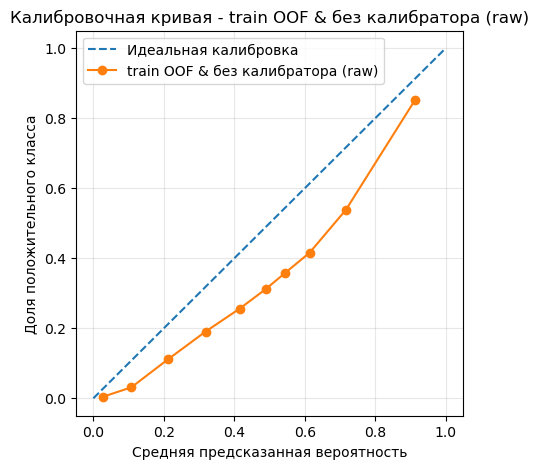

Model     : train OOF & без калибратора (raw)
ROC-AUC   : 0.815991
Brier     : 0.172106
LogLoss   : 0.504302
Mean abs calibration gap: 0.128721

   mean_predicted_proba  observed_positive_rate  abs_gap
0                 0.027                   0.004    0.023
1                 0.108                   0.031    0.077
2                 0.211                   0.111    0.100
3                 0.318                   0.190    0.128
4                 0.415                   0.256    0.159
5                 0.489                   0.312    0.177
6                 0.544                   0.358    0.186
7                 0.613                   0.415    0.198
8                 0.717                   0.538    0.178
9                 0.913                   0.853    0.061

Интерпретация с raw (без калибратора):
Калибровка нарушена.
Если линия ниже идеальной диагонали, модель переоценивает вероятности.
Если линия ниже идеальной диагонали: модель недооценивает вероятности.


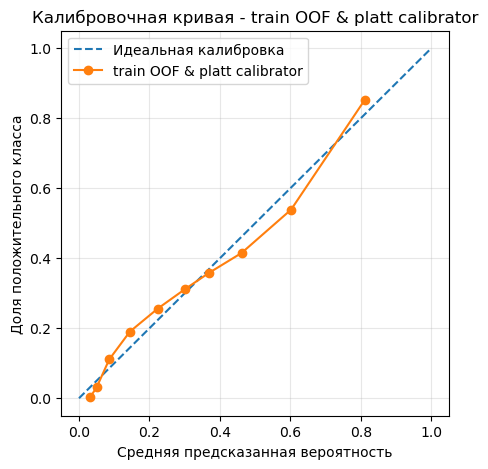

Model     : train OOF & platt calibrator
ROC-AUC   : 0.815990
Brier     : 0.153618
LogLoss   : 0.463541
Mean abs calibration gap: 0.032301

   mean_predicted_proba  observed_positive_rate  abs_gap
0                 0.032                   0.004    0.028
1                 0.050                   0.031    0.019
2                 0.086                   0.111    0.025
3                 0.144                   0.190    0.046
4                 0.224                   0.256    0.033
5                 0.301                   0.312    0.011
6                 0.369                   0.358    0.011
7                 0.462                   0.415    0.046
8                 0.602                   0.539    0.063
9                 0.811                   0.853    0.041

Интерпретация с platt calibrator:
Калибровка приемлемая.


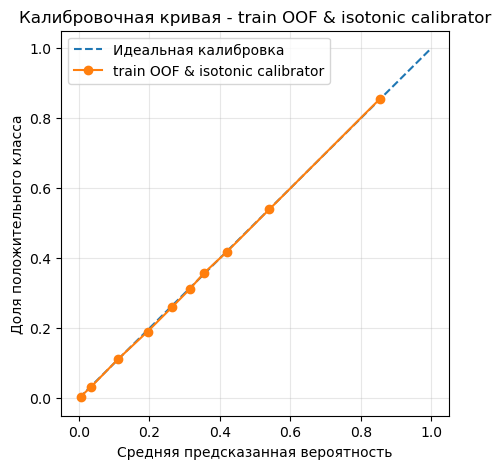

Model     : train OOF & isotonic calibrator
ROC-AUC   : 0.815806
Brier     : 0.151877
LogLoss   : 0.455045
Mean abs calibration gap: 0.001936

   mean_predicted_proba  observed_positive_rate  abs_gap
0                 0.004                   0.005    0.000
1                 0.033                   0.031    0.002
2                 0.111                   0.112    0.001
3                 0.195                   0.190    0.004
4                 0.263                   0.259    0.004
5                 0.315                   0.312    0.003
6                 0.355                   0.358    0.003
7                 0.419                   0.418    0.001
8                 0.540                   0.540    0.001
9                 0.853                   0.855    0.001

Интерпретация с isotonic calibrator:
Калибровка достаточно хорошая.

Сравнение на OOF
    version  roc_auc  brier  logloss  mean_abs_gap  max_abs_gap
0  isotonic    0.816  0.152    0.455         0.002        0.004
1     platt    

In [40]:
_validate_binary_target(y_train_valid)
_validate_binary_target(y_test)

calibrators = {
    'platt': PlattCalibrator(),
    'isotonic': IsotonicCalibrator()}

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=43)

p_oof_raw, p_oof_calibrated_dict = get_crossfitted_oof_probabilities(
    estimator=models[best_model_name]['model'],
    X=x_train_valid,
    y=y_train_valid,
    outer_cv=outer_cv,
    inner_cv=inner_cv,
    calibrators=calibrators,
    verbose=True)

raw_result = evaluate_probabilities(
    y_true=y_train_valid,
    y_prob=p_oof_raw,
    label='train OOF & без калибратора (raw)',
    n_bins=10,
    strategy='quantile',
    show_plot=True,
    print_report=True)

print('\nИнтерпретация с raw (без калибратора):')
interpret_calibration(raw_result['calibration_table'])

platt_result = evaluate_probabilities(
    y_true=y_train_valid,
    y_prob=p_oof_calibrated_dict['platt'],
    label='train OOF & platt calibrator',
    n_bins=10,
    strategy='quantile',
    show_plot=True,
    print_report=True)

print('\nИнтерпретация с platt calibrator:')
interpret_calibration(platt_result['calibration_table'])

isotonic_result = evaluate_probabilities(
    y_true=y_train_valid,
    y_prob=p_oof_calibrated_dict['isotonic'],
    label='train OOF & isotonic calibrator',
    n_bins=10,
    strategy='quantile',
    show_plot=True,
    print_report=True)

print('\nИнтерпретация с isotonic calibrator:')
interpret_calibration(isotonic_result['calibration_table'])

prob_versions = {
    'raw': p_oof_raw,
    'platt': p_oof_calibrated_dict['platt'],
    'isotonic': p_oof_calibrated_dict['isotonic']}

comparison_calibration, calibration_tables = compare_probability_versions(
    y_true=y_train_valid,
    prob_dict=prob_versions,
    n_bins=10,
    strategy='quantile',
    plot_each=False,
    print_tables=False)

print('\nСравнение на OOF')
print(comparison_calibration)

In [41]:
# для автоматического выбора лучшей версии
# manual_selected_version = None

# тут можно выбрать 'raw', 'platt', 'isotonic' или None
manual_selected_version = None

if manual_selected_version is None:
    selected_version = comparison_calibration.loc[0, 'version']
    print('Автоматически выбранный вариант:', selected_version)
else:
    selected_version = manual_selected_version
    print('Вручную выбранный вариант:', selected_version)

if selected_version == 'raw':
    p_oof_selected = p_oof_raw
else:
    p_oof_selected = p_oof_calibrated_dict[selected_version]

best_threshold_f1, threshold_table_f1 = find_best_threshold(
    y_true=y_train_valid,
    y_score=p_oof_selected,
    metric='f1')

print('\nВыбранный вариант:', selected_version)
print('Лучший порог по F1:', best_threshold_f1)
print(threshold_table_f1.head(10))

best_threshold_mcc, threshold_table_mcc = find_best_threshold(
    y_true=y_train_valid,
    y_score=p_oof_selected,
    metric='mcc')

print('\nВыбранный вариант:', selected_version)
print('Лучший порог по MCC:', best_threshold_mcc)
print(threshold_table_mcc.head(10))

Автоматически выбранный вариант: isotonic

Выбранный вариант: isotonic
Лучший порог по F1: 0.31
   threshold  metric_value  precision  recall    f1   mcc
0      0.310         0.615      0.512   0.768 0.615 0.411
1      0.300         0.614      0.502   0.791 0.614 0.409
2      0.320         0.614      0.520   0.748 0.614 0.412
3      0.330         0.613      0.535   0.719 0.613 0.414
4      0.290         0.613      0.494   0.808 0.613 0.407
5      0.280         0.612      0.486   0.826 0.612 0.406
6      0.270         0.611      0.481   0.838 0.611 0.404
7      0.340         0.611      0.547   0.692 0.611 0.415
8      0.260         0.610      0.475   0.851 0.610 0.403
9      0.250         0.608      0.470   0.863 0.608 0.401

Выбранный вариант: isotonic
Лучший порог по MCC: 0.44
   threshold  metric_value  precision  recall    f1   mcc
0      0.440         0.423      0.666   0.494 0.568 0.423
1      0.450         0.423      0.674   0.483 0.563 0.423
2      0.430         0.423      0.658

In [42]:
final_model, final_calibrator = fit_final_model_and_calibrator(
    estimator=models[best_model_name]['model'],
    X_train=x_train_valid,
    y_train=y_train_valid,
    selected_version=selected_version,
    p_oof_raw_train=p_oof_raw,
    final_calibration_mode='strict_oof')

p_test_selected = predict_final_proba(final_model, final_calibrator, x_test)

test_result_selected = evaluate_on_test(
    y_true=y_test,
    y_prob=p_test_selected,
    threshold_f1=best_threshold_f1,
    threshold_mcc=best_threshold_mcc)

print('\nМетрики на тестовой выборке при выбранном варианте')
print(test_result_selected['probability_metrics'])

print('\nМетрики на тестовой выборке при пороге, выбранном по F1, и выбранном варианте')
print(test_result_selected['threshold_f1_metrics'])

print('\nМетрики на тестовой выборке при пороге, выбранном по MCC, и выбранном варианте')
print(test_result_selected['threshold_mcc_metrics'])


Метрики на тестовой выборке при выбранном варианте
{'roc_auc': 0.7772320683304895, 'brier': 0.14984593236816177, 'logloss': 0.4578658129388741}

Метрики на тестовой выборке при пороге, выбранном по F1, и выбранном варианте
{'threshold': 0.31, 'precision': 0.3778857837181045, 'recall': 0.7031810385155154, 'f1': 0.4915924018205107, 'mcc': 0.32927386282735727, 'tn': 33208, 'fp': 14848, 'fn': 3807, 'tp': 9019}

Метрики на тестовой выборке при пороге, выбранном по MCC, и выбранном варианте
{'threshold': 0.44, 'precision': 0.4395671859412171, 'recall': 0.44659285825666617, 'f1': 0.4430521715589589, 'mcc': 0.2929231132277448, 'tn': 40753, 'fp': 7303, 'fn': 7098, 'tp': 5728}



Метрики на тестовой выборке при выбранном варианте raw
{'roc_auc': 0.777305176648087, 'brier': 0.18882500662884674, 'logloss': 0.5586525543011805}

Метрики на тестовой выборке при пороге, выбранном по F1, и выбранном варианте raw
{'threshold': 0.49, 'precision': 0.3780359914425941, 'recall': 0.7026352721035397, 'f1': 0.49158598118096275, 'mcc': 0.3292517601322095, 'tn': 33229, 'fp': 14827, 'fn': 3814, 'tp': 9012}

Метрики на тестовой выборке при пороге, выбранном по MCC, и выбранном варианте raw
{'threshold': 0.64, 'precision': 0.43933795227097766, 'recall': 0.44495555902073913, 'f1': 0.4421289123024481, 'mcc': 0.29204395151828805, 'tn': 40773, 'fp': 7283, 'fn': 7119, 'tp': 5707}


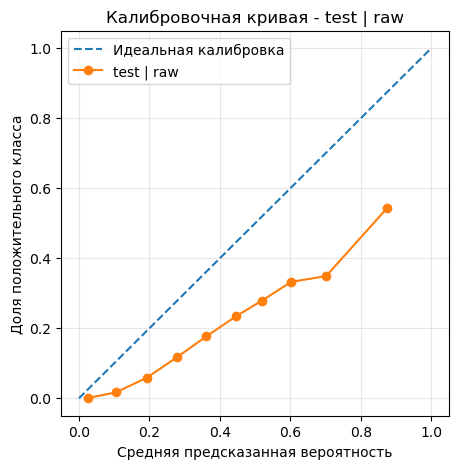

Model     : test | raw
ROC-AUC   : 0.777305
Brier     : 0.188825
LogLoss   : 0.558653
Mean abs calibration gap: 0.199859

   mean_predicted_proba  observed_positive_rate  abs_gap
0                 0.026                   0.001    0.025
1                 0.104                   0.017    0.088
2                 0.193                   0.059    0.134
3                 0.278                   0.117    0.161
4                 0.361                   0.177    0.185
5                 0.446                   0.234    0.212
6                 0.519                   0.279    0.240
7                 0.602                   0.332    0.270
8                 0.702                   0.349    0.353
9                 0.874                   0.542    0.332

Метрики на тестовой выборке при выбранном варианте platt
{'roc_auc': 0.777305176648087, 'brier': 0.15210651694880778, 'logloss': 0.45655746301335276}

Метрики на тестовой выборке при пороге, выбранном по F1, и выбранном варианте platt
{'threshold': 0

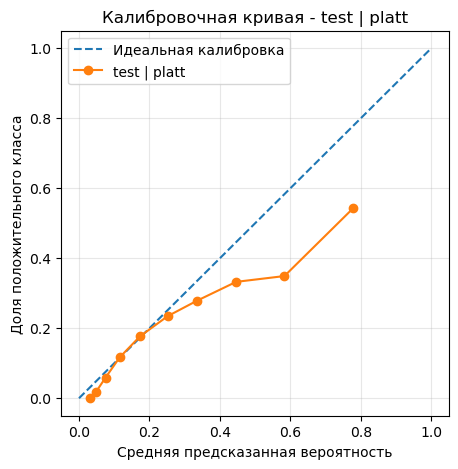

Model     : test | platt
ROC-AUC   : 0.777305
Brier     : 0.152107
LogLoss   : 0.456557
Mean abs calibration gap: 0.073825

   mean_predicted_proba  observed_positive_rate  abs_gap
0                 0.031                   0.001    0.030
1                 0.047                   0.017    0.031
2                 0.075                   0.059    0.016
3                 0.116                   0.117    0.001
4                 0.173                   0.177    0.004
5                 0.251                   0.234    0.017
6                 0.335                   0.279    0.056
7                 0.446                   0.332    0.114
8                 0.583                   0.349    0.234
9                 0.778                   0.542    0.235

Метрики на тестовой выборке при выбранном варианте isotonic
{'roc_auc': 0.7772320683304895, 'brier': 0.14984593236816177, 'logloss': 0.4578658129388741}

Метрики на тестовой выборке при пороге, выбранном по F1, и выбранном варианте isotonic
{'thres

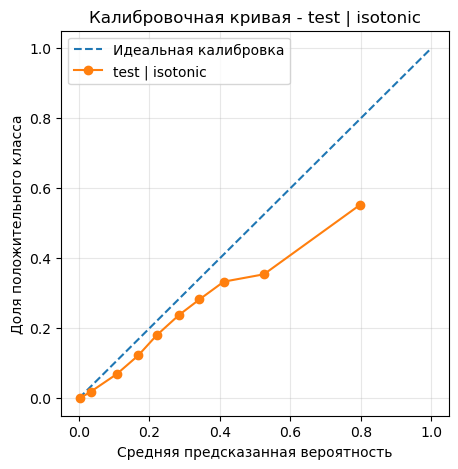

Model     : test | isotonic
ROC-AUC   : 0.777232
Brier     : 0.149846
LogLoss   : 0.457866
Mean abs calibration gap: 0.074175

   mean_predicted_proba  observed_positive_rate  abs_gap
0                 0.004                   0.001    0.003
1                 0.033                   0.018    0.014
2                 0.107                   0.069    0.038
3                 0.168                   0.122    0.046
4                 0.220                   0.180    0.041
5                 0.284                   0.238    0.046
6                 0.342                   0.282    0.060
7                 0.411                   0.333    0.078
8                 0.525                   0.354    0.171
9                 0.799                   0.553    0.245

Сравнение на тестовой выборке варианта raw, platt и isotonic calibrator
    version  roc_auc  brier  logloss  threshold_f1  test_f1_at_best_f1_thr  \
0  isotonic    0.777  0.150    0.458         0.310                   0.492   
1     platt    0.

In [43]:
test_results_all = {}
test_summary_rows = []

for version in ['raw', 'platt', 'isotonic']:
    final_model_i, final_calibrator_i = fit_final_model_and_calibrator(
        estimator=models[best_model_name]['model'],
        X_train=x_train_valid,
        y_train=y_train_valid,
        selected_version=version,
        p_oof_raw_train=p_oof_raw,
        final_calibration_mode='strict_oof')

    p_test_i = predict_final_proba(final_model_i, final_calibrator_i, x_test)

    if version == 'raw':
        p_oof_version = p_oof_raw
    else:
        p_oof_version = p_oof_calibrated_dict[version]

    best_threshold_f1_i, threshold_table_f1_i = find_best_threshold(
        y_true=y_train_valid,
        y_score=p_oof_version,
        metric='f1')

    best_threshold_mcc_i, threshold_table_mcc_i = find_best_threshold(
        y_true=y_train_valid,
        y_score=p_oof_version,
        metric='mcc')

    test_result_i = evaluate_on_test(
        y_true=y_test,
        y_prob=p_test_i,
        threshold_f1=best_threshold_f1_i,
        threshold_mcc=best_threshold_mcc_i)

    print(f'\nМетрики на тестовой выборке при выбранном варианте {version}')
    print(test_result_i['probability_metrics'])

    print(f'\nМетрики на тестовой выборке при пороге, выбранном по F1, и выбранном варианте {version}')
    print(test_result_i['threshold_f1_metrics'])

    print(f'\nМетрики на тестовой выборке при пороге, выбранном по MCC, и выбранном варианте {version}')
    print(test_result_i['threshold_mcc_metrics'])

    test_calibration_i = evaluate_probabilities(
        y_true=y_test,
        y_prob=p_test_i,
        label=f'test | {version}',
        n_bins=10,
        strategy='quantile',
        show_plot=True,
        print_report=True)

    test_results_all[version] = {
        'p_test': p_test_i,
        'probability_metrics': test_result_i['probability_metrics'],
        'threshold_f1': best_threshold_f1_i,
        'threshold_mcc': best_threshold_mcc_i,
        'threshold_f1_metrics': test_result_i['threshold_f1_metrics'],
        'threshold_mcc_metrics': test_result_i['threshold_mcc_metrics'],
        'calibration_table': test_calibration_i['calibration_table'],
        'threshold_table_f1': threshold_table_f1_i,
        'threshold_table_mcc': threshold_table_mcc_i}

    test_summary_rows.append({
        'version': version,
        'roc_auc': test_result_i['probability_metrics']['roc_auc'],
        'brier': test_result_i['probability_metrics']['brier'],
        'logloss': test_result_i['probability_metrics']['logloss'],
        'threshold_f1': best_threshold_f1_i,
        'test_f1_at_best_f1_thr': test_result_i['threshold_f1_metrics']['f1'],
        'test_precision_at_best_f1_thr': test_result_i['threshold_f1_metrics']['precision'],
        'test_recall_at_best_f1_thr': test_result_i['threshold_f1_metrics']['recall'],
        'threshold_mcc': best_threshold_mcc_i,
        'test_mcc_at_best_mcc_thr': test_result_i['threshold_mcc_metrics']['mcc'],
        'test_f1_at_best_mcc_thr': test_result_i['threshold_mcc_metrics']['f1']})

test_comparison_df = (
    pd.DataFrame(test_summary_rows)
    .sort_values(by=['brier', 'logloss'], ascending=[True, True])
    .reset_index(drop=True))

print('\nСравнение на тестовой выборке варианта raw, platt и isotonic calibrator')
print(test_comparison_df)

best_test_version = test_comparison_df.loc[0, 'version']
print('\nЛучшая версия на тестовой выборке по метрикам Brier/LogLoss:', best_test_version)

## Дальнейшее использование модели

In [44]:
# подобран на основе финансовой оценки результатов внедрения модели
custom_threshold = 0.77

In [45]:
# то, что пойдет на прод в формате joblib
inference_artifacts = {
    'model': final_model,
    # тут нужно указать None, если выбран raw
    'calibrator': final_calibrator,
    # или best_threshold_mcc, или свой порог
    'threshold': custom_threshold,
    'feature_names': list(x_train_valid.columns)}

In [46]:
# joblib.dump(inference_artifacts, 'model_artifacts.joblib')

In [47]:
def predict_proba_inference(artifacts, X):
    model = artifacts['model']
    calibrator = artifacts['calibrator']
    feature_names = artifacts['feature_names']

    if isinstance(X, pd.DataFrame):
        X = X[feature_names]

    p_raw = model.predict_proba(X)[:, 1]

    if calibrator is None:
        return p_raw

    return calibrator.predict_proba(p_raw)

def predict_class_inference(artifacts, X):
    threshold = artifacts['threshold']
    p = predict_proba_inference(artifacts, X)
    y_pred = (p >= threshold).astype(int)
    return y_pred

In [48]:
y_test_proba = predict_proba_inference(inference_artifacts, x_test)

y_test_preds = predict_class_inference(inference_artifacts, x_test)

In [49]:
test_ci = bootstrap_ci(
    y_true=y_test.values if hasattr(y_test, 'values') else y_test,
    y_score=y_test_proba,
    y_pred=y_test_preds,
    n_bootstrap=1000,
    random_state=RANDOM_STATE)

test_ci.loc[[0]]

,metric,mean,ci_lower_95,ci_upper_95
0,roc_auc,0.777,0.773,0.781



Матрица ошибок:
[[0.77165665 0.01767353]
 [0.18169574 0.02897408]]

Classification report:
              precision    recall  f1-score   support

           0     0.8094    0.9776    0.8856     48056
           1     0.6211    0.1375    0.2252     12826

    accuracy                         0.8006     60882
   macro avg     0.7153    0.5576    0.5554     60882
weighted avg     0.7697    0.8006    0.7465     60882



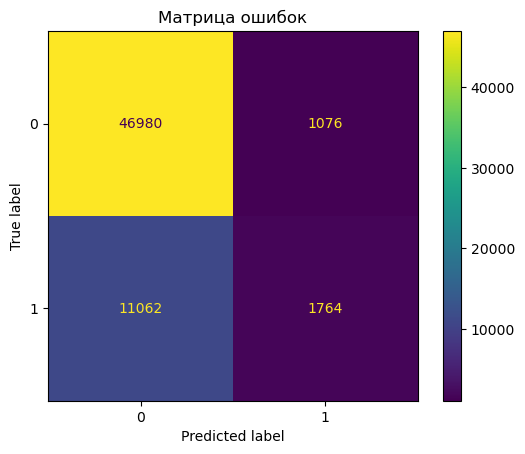

In [50]:
cm = confusion_matrix(y_test, y_test_preds, labels=[0, 1])
cm_norm = confusion_matrix(y_test, y_test_preds, labels=[0, 1], normalize='all')

print('\nМатрица ошибок:')
print(cm_norm)

print('\nClassification report:')
print(classification_report(y_test, y_test_preds, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1])

disp.plot(values_format='d')
plt.title('Матрица ошибок')
plt.show()